# Детекция аномалий и редких событий в сильно несбалансированных данных

В датасете 284 807 транзакций, из них мошеннических 0.17%. При таком перекосе модель, предсказывающая «всё легально», получает accuracy 99.8% и совершенно бесполезна. Здесь я разбираюсь, что в такой ситуации работает на самом деле: какие метрики не врут, помогает ли передискретизация, и можно ли обойтись вообще без разметки.

Данные — открытый Kaggle-датасет Credit Card Fraud Detection, признаки обезличены PCA-преобразованием.

Работа состоит из двух частей. В первой — supervised-подход: подбор адекватных метрик (PR-AUC, каппа Коэна, коэффициент корреляции Мэтьюза), взвешивание функции потерь, семейство SMOTE (Borderline, SVM, K-Means, ADASYN) и методы андерсэмплинга (Random, NearMiss, Tomek Links). Во второй — поиск аномалий без учителя: реализация Extended Isolation Forest с нуля (вместо осевых порогов случайные гиперплоскости, [статья](https://arxiv.org/pdf/1811.02141.pdf)), сравнение с Isolation Forest из sklearn, Local Outlier Factor и One-Class SVM. В конце оценки аномальности от unsupervised-методов идут признаками в CatBoost.

Стек: Python, CatBoost, scikit-learn, imbalanced-learn, numpy/pandas.

---


## Постановка задачи

Проект разбирает основные подходы к бинарной классификации в условиях сильного дисбаланса классов — на практике с этим сталкивается любая задача детекции редких событий: мошеннические транзакции, отказы оборудования, аварии, хищения. Методы рассмотрены на бинарной постановке, но большинство переносится и на многоклассовый случай.

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

## Разведочный анализ данных (EDA)

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [4]:
"""%%bash
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip creditcardfraud.zip""";

In [5]:
df = pd.read_csv('creditcard.csv')

In [6]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Данные обезличены. Есть 30 признаков, из которых 28 — результат PCA-преобразования исходного датасета. Ещё два признака: время в секундах, прошедшее с момента первой транзакции, и размер транзакции. Первым делом посмотрим, какова доля положительных объектов в выборке.

In [12]:
fraud_count = df['Class'].sum()
total_count = len(df)
fraud_rate = df['Class'].mean()

print(f"Всего транзакций: {total_count:,}")
print(f"Мошеннических транзакций: {fraud_count:,}")
print(f"Доля положительных: {fraud_rate:.4%}")

Всего транзакций: 284,807
Мошеннических транзакций: 492
Доля положительных: 0.1727%


Начнём с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, поэтому создам по ним признаки «час» (от 0 до 23) и «день», приняв первый объект выборки за начальную точку. Заодно посмотрим, сколько дней покрывают данные.

In [15]:
df['hour'] = (df['Time'] // 3600) % 24
df['day'] = (df['Time'] // 86400).astype(int)

print(f"Данные покрывают дней: {df['day'].max() + 1}")
print(df[['Time', 'hour', 'day']].head(10))

Данные покрывают дней: 2
   Time  hour  day
0   0.0   0.0    0
1   0.0   0.0    0
2   1.0   0.0    0
3   1.0   0.0    0
4   2.0   0.0    0
5   2.0   0.0    0
6   4.0   0.0    0
7   7.0   0.0    0
8   7.0   0.0    0
9   9.0   0.0    0


Построим три графика:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot).
3. То же самое для дней (здесь удобнее bar-plot, дней немного).

Заодно попробуем сопоставить полученные часы с реальными часами в сутках.

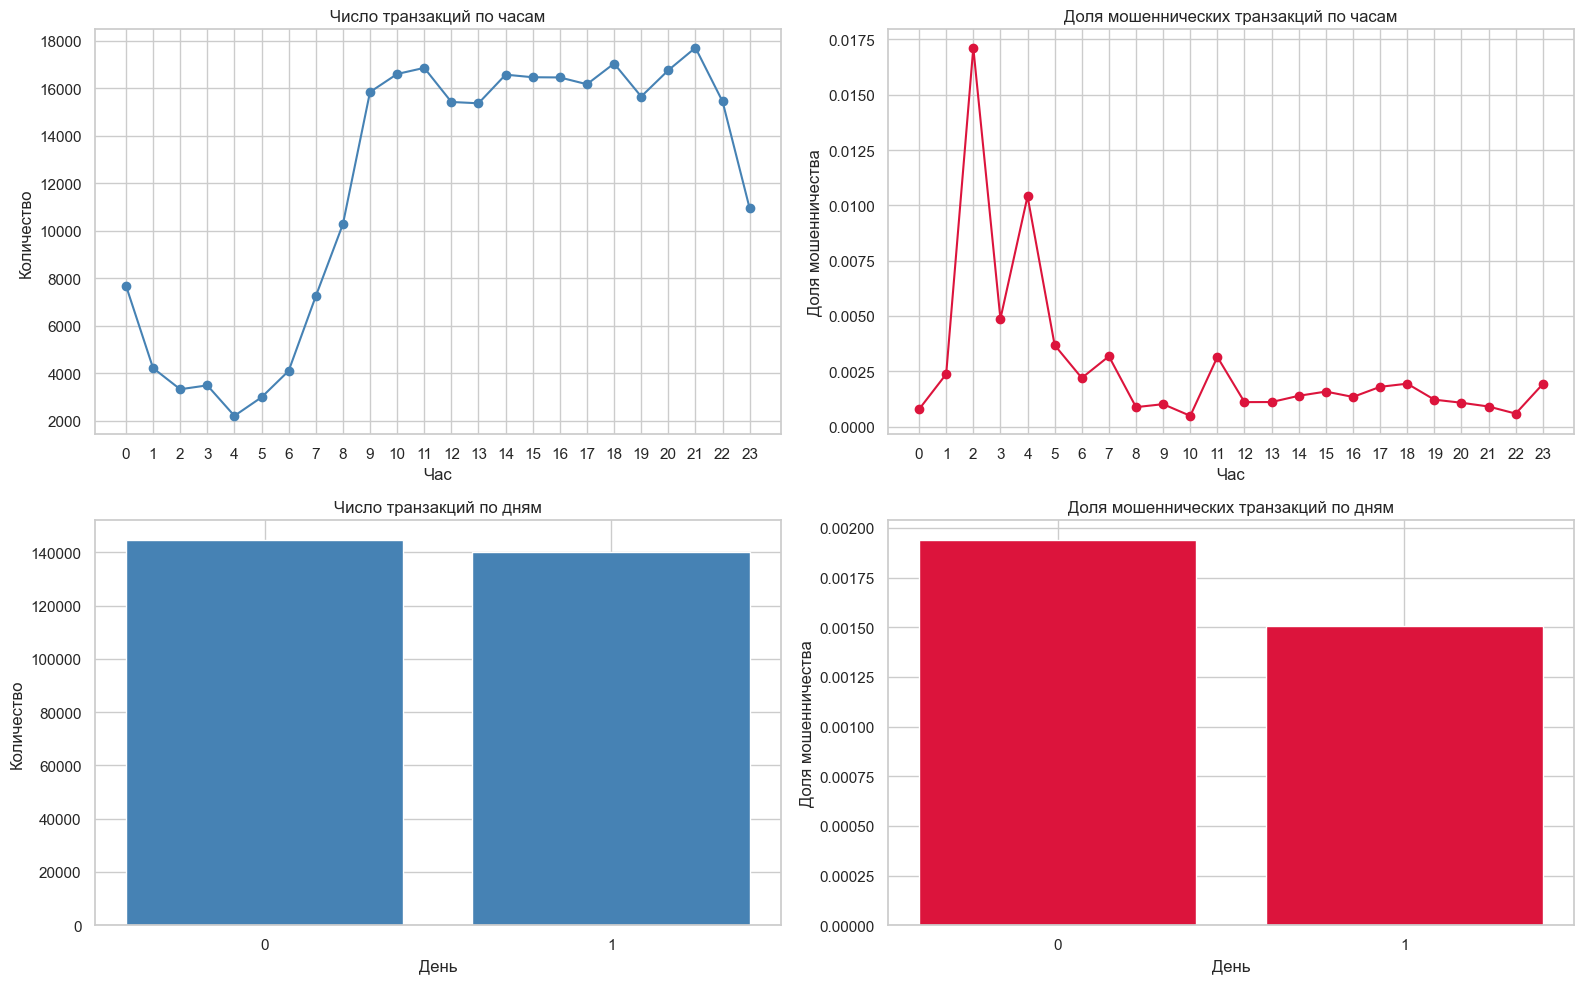

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

hourly = df.groupby('hour').agg(
    total=('Class', 'count'),
    fraud=('Class', 'sum')
).reset_index()
hourly['fraud_rate'] = hourly['fraud'] / hourly['total']

daily = df.groupby('day').agg(
    total=('Class', 'count'),
    fraud=('Class', 'sum')
).reset_index()
daily['fraud_rate'] = daily['fraud'] / daily['total']


axes[0, 0].plot(hourly['hour'], hourly['total'], marker='o', color='steelblue')
axes[0, 0].set_title('Число транзакций по часам')
axes[0, 0].set_xlabel('Час')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xticks(range(24))


axes[0, 1].plot(hourly['hour'], hourly['fraud_rate'], marker='o', color='crimson')
axes[0, 1].set_title('Доля мошеннических транзакций по часам')
axes[0, 1].set_xlabel('Час')
axes[0, 1].set_ylabel('Доля мошенничества')
axes[0, 1].set_xticks(range(24))


axes[1, 0].bar(daily['day'], daily['total'], color='steelblue')
axes[1, 0].set_title('Число транзакций по дням')
axes[1, 0].set_xlabel('День')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].set_xticks(daily['day'])


axes[1, 1].bar(daily['day'], daily['fraud_rate'], color='crimson')
axes[1, 1].set_title('Доля мошеннических транзакций по дням')
axes[1, 1].set_xlabel('День')
axes[1, 1].set_ylabel('Доля мошенничества')
axes[1, 1].set_xticks(daily['day'])

plt.tight_layout()
plt.show()

> Минимум транзакционной активности глубокой ночью, далее количество транзакций растет с 6-7 часов утра. Пики активности держутся с 9 утра и до 22 часа

> Мошенники активно работают, когда обычных транзакций и активности мало : с 1 до 6-7 утра. Позднее их активность держится в пределах минимума влоть до полуночи со странным, также эмпирически проверенным вне рамок этого ноутбука,  локальным максимумом в 11 часов утра.

> Число транзакций по дням примерно одинаково. Однако в крайний день падение числа транзакций примерно на 2% сопровождалось 23% падением доли мошшеничества. 

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуем (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

Наиболее коррелированные с Class признаки:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
Name: Class, dtype: float64


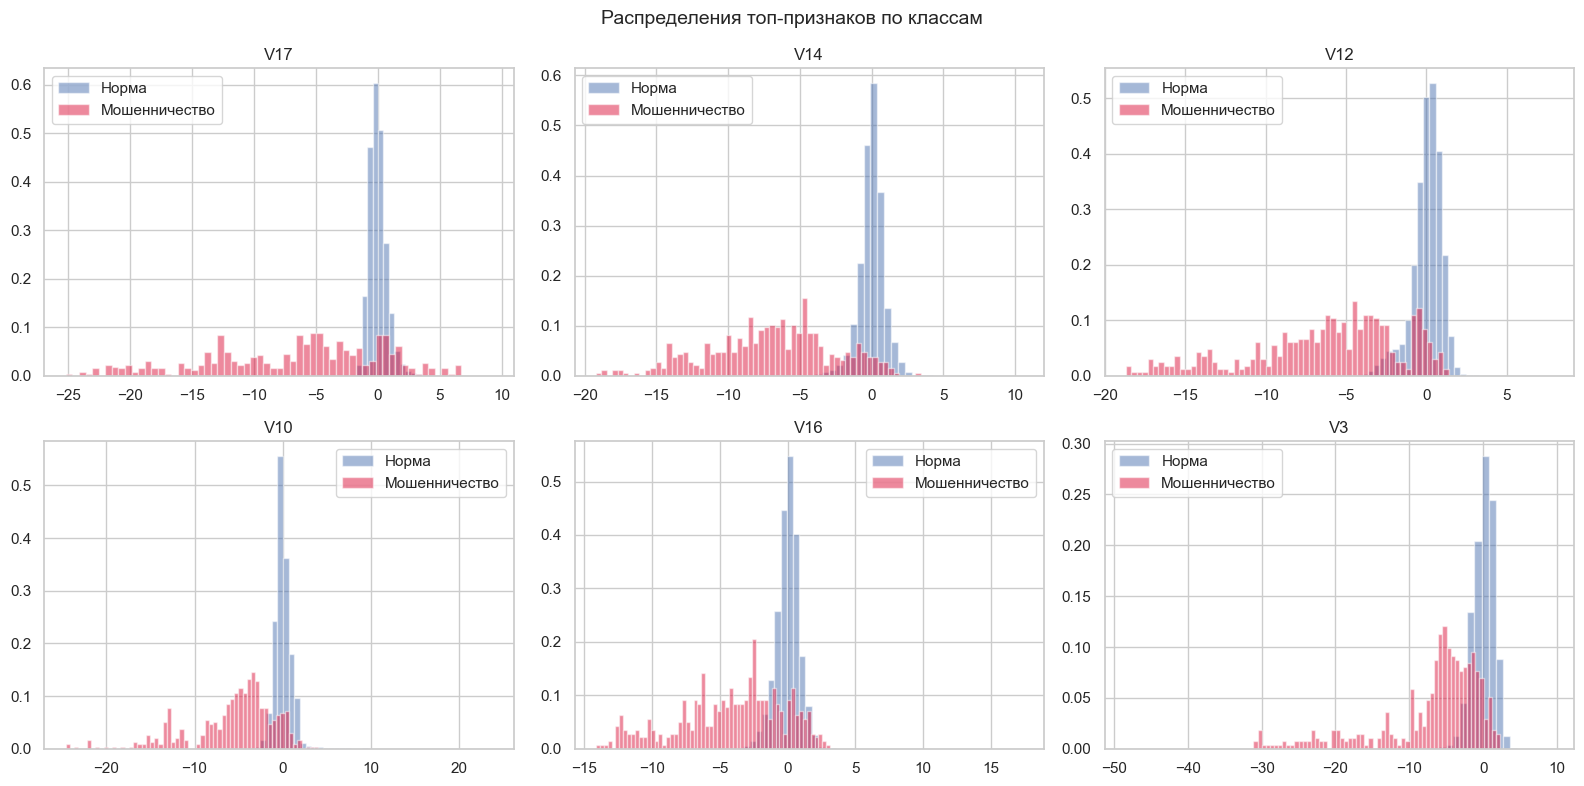

In [22]:
corr_with_target = df.drop(columns=['Time', 'hour', 'day']).corr()['Class'].drop('Class')
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index.tolist()

print("Наиболее коррелированные с Class признаки:")
print(corr_with_target[top_features])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), top_features):
    df[df['Class'] == 0][feat].hist(
        bins=60, alpha=0.5, label='Норма', ax=ax, density=True
    )
    df[df['Class'] == 1][feat].hist(
        bins=60, alpha=0.5, label='Мошенничество',
        ax=ax, density=True, color='crimson'
    )
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Распределения топ-признаков по классам', fontsize=14)
plt.tight_layout()
plt.show()

> V3 улавливает два разных мошеннических поведения 

Теперь разделим данные. Отделим хронологически последние 20% транзакций и поделим их пополам, тоже хронологически, без перемешивания, на валидационные и тестовые. Разбиение не совсем корректно: мошеннические транзакции распределены во времени неравномерно, и по-хорошему стоило бы выделить под валидацию и тест целые сутки записей. Но больше данных для адекватного контроля взять неоткуда, поэтому обойдусь этим.

In [30]:
n = len(df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

print(f"Train: {len(train)} строк | fraud: {train['Class'].sum()} ({train['Class'].mean():.3%})")
print(f"Val: {len(val):>6} строк   | fraud: {val['Class'].sum()} ({val['Class'].mean():.3%})")
print(f"Test:{len(test):>6} строк   | fraud:{test['Class'].sum()} ({test['Class'].mean():.3%})")

Train: 227845 строк | fraud: 417 (0.183%)
Val:  28481 строк   | fraud: 53 (0.186%)
Test: 28481 строк   | fraud:22 (0.077%)


# Часть 1. Несбалансированная классификация.

Перед началом работы стоит определиться с тем, как оценивать качество. Классические метрики для качества классификации чаще всего «ломаются» на задачах с сильным перекосом классов. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)?

В таких задачах вместо этого можно использовать `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога.

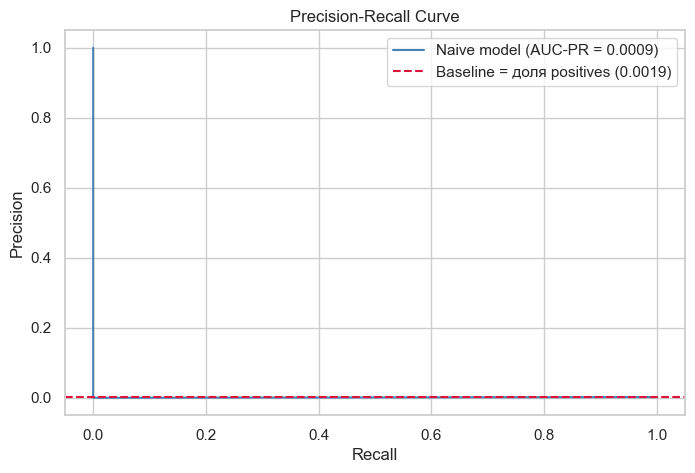

AUC-PR наивной модели: 0.0009
Доля положительных:    0.0019


In [36]:
from sklearn.metrics import precision_recall_curve, auc
from sklearn.dummy import DummyClassifier

 
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(train.drop(columns='Class'), train['Class'])
dummy_proba = dummy.predict_proba(val.drop(columns='Class'))[:, 1]

precision, recall, thresholds = precision_recall_curve(val['Class'], dummy_proba)
auc_pr = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='steelblue', label=f'Naive model (AUC-PR = {auc_pr:.4f})')
plt.axhline(y=val['Class'].mean(), color='crimson', linestyle='--', 
            label=f'Baseline = доля positives ({val["Class"].mean():.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

print(f"AUC-PR наивной модели: {auc_pr:.4f}")
print(f"Доля положительных:    {val['Class'].mean():.4f}")

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можно использовать это для отладки):

In [39]:
def cohen_kappa(y_true, y_pred):
    p_o = (y_true == y_pred).mean()
    
    p_true_pos = y_true.mean()
    p_true_neg = 1 - p_true_pos
    p_pred_pos = y_pred.mean()
    p_pred_neg = 1 - p_pred_pos
    
    p_e = p_true_pos * p_pred_pos + p_true_neg * p_pred_neg
    
    kappa = (p_o - p_e) / (1 - p_e)
    return kappa


naive_pred = np.zeros(len(val), dtype=int)  
kappa = cohen_kappa(val['Class'].values, naive_pred)
print(f"Kappa наивной модели: {kappa:.4f}") 

kappa_1 = cohen_kappa(val['Class'].values, naive_pred)
kappa_2 = cohen_kappa(naive_pred, val['Class'].values)
print(f"Симметричность: {kappa_1:.6f} == {kappa_2:.6f}  {np.isclose(kappa_1, kappa_2)}")

kappa_perfect = cohen_kappa(val['Class'].values, val['Class'].values)
print(f"Kappa идеальной модели: {kappa_perfect:.4f}")  

Kappa наивной модели: 0.0000
Симметричность: 0.000000 == 0.000000  True
Kappa идеальной модели: 1.0000


Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$ 

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом. 

In [42]:
def mcc(y_true, y_pred):
    TP = float(((y_true == 1) & (y_pred == 1)).sum())
    TN = float(((y_true == 0) & (y_pred == 0)).sum())
    FP = float(((y_true == 0) & (y_pred == 1)).sum())
    FN = float(((y_true == 1) & (y_pred == 0)).sum())
    
    numerator   = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    
    if denominator == 0:
        return 0.0
    
    return numerator / denominator

naive_pred = np.zeros(len(val), dtype=int)

print(f"MCC наивной модели: {mcc(val['Class'].values, naive_pred):.4f}")   
print(f"MCC идеальной модели: {mcc(val['Class'].values, val['Class'].values):.4f}")  

print(f"Симметричность: {np.isclose(mcc(val['Class'].values, naive_pred), mcc(naive_pred, val['Class'].values))}")

MCC наивной модели: 0.0000
MCC идеальной модели: 1.0000
Симметричность: True


Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Проверим, что метрики действительно подходят под задачу. Вычислим их значения для наивного предсказания, то есть мажорного класса для всех объектов:

In [46]:
naive_pred = np.zeros(len(val), dtype=int)  

kappa = cohen_kappa(val['Class'].values, naive_pred)
mcc_score = mcc(val['Class'].values, naive_pred)

print(f"Accuracy наивной модели: {(val['Class'].values == naive_pred).mean():.4%}")
print(f"Kappa наивной модели: {kappa:.4f}")
print(f"MCC наивной модели: {mcc_score:.4f}")

Accuracy наивной модели: 99.8139%
Kappa наивной модели: 0.0000
MCC наивной модели: 0.0000


Запустим бейзлайн. Возьмём `catboost` и обучим его классификатор на всех признаках. Значения всех метрик считаем на тестовой части, для контроля переобучения используем валидационную — здесь и далее везде, где фигурирует `catboost`.

In [49]:
from catboost import CatBoostClassifier

In [51]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

def mcc(y_true, y_pred):
    TP = float(((y_true == 1) & (y_pred == 1)).sum())
    TN = float(((y_true == 0) & (y_pred == 0)).sum())
    FP = float(((y_true == 0) & (y_pred == 1)).sum())
    FN = float(((y_true == 1) & (y_pred == 0)).sum())
    numerator   = TP * TN - FP * FN
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return 0.0 if denominator == 0 else numerator / denominator

def cohen_kappa(y_true, y_pred):
    p_o = (y_true == y_pred).mean()
    p_e = y_true.mean() * y_pred.mean() + (1 - y_true.mean()) * (1 - y_pred.mean())
    return (p_o - p_e) / (1 - p_e)

def find_best_threshold(y_true, y_proba, metric='mcc'):
    _, _, thresholds = precision_recall_curve(y_true, y_proba)
    best_thresh, best_score = 0.5, -np.inf
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        score  = mcc(y_true, y_pred) if metric == 'mcc' else cohen_kappa(y_true, y_pred)
        if score > best_score:
            best_score, best_thresh = score, thresh
    return best_thresh, best_score


features = [c for c in df.columns if c not in ['Class', 'Time']]
X_train, y_train = train[features], train['Class']
X_val,   y_val = val[features],   val['Class']
X_test,  y_test = test[features],  test['Class']


model = CatBoostClassifier(iterations=1000, eval_metric='AUC', random_seed=42, verbose=100)
model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)


y_val_proba = model.predict_proba(X_val)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

best_thresh, _ = find_best_threshold(y_val.values, y_val_proba, metric='mcc')
y_test_pred = (y_test_proba >= best_thresh).astype(int)

print(f"Лучший порог (по MCC на val): {best_thresh:.4f}")
print("\nМетрики на TEST")
print(f"Accuracy: {(y_test.values == y_test_pred).mean():.4%}")
print(f"Kappa: {cohen_kappa(y_test.values, y_test_pred):.4f}")
print(f"MCC: {mcc(y_test.values, y_test_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"AUC-PR: {average_precision_score(y_test, y_test_proba):.4f}")

Learning rate set to 0.121128
0:	test: 0.9253968	best: 0.9253968 (0)	total: 184ms	remaining: 3m 3s
100:	test: 0.9941773	best: 0.9943983 (84)	total: 1.76s	remaining: 15.7s
200:	test: 0.9954038	best: 0.9958863 (181)	total: 3.33s	remaining: 13.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9958863305
bestIteration = 181

Shrink model to first 182 iterations.
Лучший порог (по MCC на val): 0.2313

Метрики на TEST
Accuracy: 99.9614%
Kappa: 0.7315
MCC: 0.7335
AUC-ROC: 0.9560
AUC-PR: 0.7003


Значения метрик у бейзлайна получаются в районе 0.7.

Многие реализации методов предлагают встроенные способы борьбы с дисбалансом. Самое распространённое решение — добавить вес в функцию потерь для минорного класса, чтобы ошибка на его объектах весила больше. В `catboost` это реализовано двумя способами; я использую отдельный скейлинг для минорного класса. Чаще всего в качестве веса берут отношение числа объектов мажорного класса к числу минорного. Обучим модель с таким скалированием и сравним метрики на тестовой части с бейзлайном.

In [57]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")  

model_weighted = CatBoostClassifier(
    iterations=1000,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    scale_pos_weight=scale_pos_weight  
)

model_weighted.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)


y_val_proba_w = model_weighted.predict_proba(X_val)[:, 1]
y_test_proba_w = model_weighted.predict_proba(X_test)[:, 1]


best_thresh_w, _ = find_best_threshold(y_val.values, y_val_proba_w, metric='mcc')
y_test_pred_w = (y_test_proba_w >= best_thresh_w).astype(int)

print(f"Лучший порог (по MCC на val): {best_thresh_w:.4f}")
print("\nСравнение метрик на TEST")
print(f"{'Метрика':<8} {'Бейзлайн':>10} {'Weighted':>12}")
print(f"{'Accuracy':<8} {(y_test.values == y_test_pred).mean():>10.4%} {(y_test.values == y_test_pred_w).mean():>12.4%}")
print(f"{'Kappa':<8} {cohen_kappa(y_test.values, y_test_pred):>10.4f} {cohen_kappa(y_test.values, y_test_pred_w):>12.4f}")
print(f"{'MCC':<8} {mcc(y_test.values, y_test_pred):>10.4f} {mcc(y_test.values, y_test_pred_w):>12.4f}")
print(f"{'AUC-ROC':<8} {roc_auc_score(y_test, y_test_proba):>10.4f} {roc_auc_score(y_test, y_test_proba_w):>12.4f}")
print(f"{'AUC-PR':<8} {average_precision_score(y_test, y_test_proba):>10.4f} {average_precision_score(y_test, y_test_proba_w):>12.4f}")

scale_pos_weight: 545.39
Learning rate set to 0.121128
0:	test: 0.9680334	best: 0.9680334 (0)	total: 22.7ms	remaining: 22.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9848976295
bestIteration = 10

Shrink model to first 11 iterations.
Лучший порог (по MCC на val): 0.9131

Сравнение метрик на TEST
Метрика    Бейзлайн     Weighted
Accuracy   99.9614%     99.9719%
Kappa        0.7315       0.7893
MCC          0.7335       0.7994
AUC-ROC      0.9560       0.9481
AUC-PR       0.7003       0.7306


Вес минорного класса — гиперпараметр метода, и останавливаться на одном значении было бы опрометчиво. Запустим перебор по нему на валидационной выборке (ориентируясь на `PR-AUC`) и подберём оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшей пары вес-порог посчитаем все метрики на тесте.

Заодно проверим скалирование в другую сторону — вес минорного класса меньше 1 — и экстремальные значения веса, больше исходного отношения классов.

  0%|          | 0/20 [00:00<?, ?it/s]

weight=      0.10 | AUC-PR val: 0.8580
weight=      0.50 | AUC-PR val: 0.8560
weight=      1.00 | AUC-PR val: 0.8571
weight=      5.00 | AUC-PR val: 0.8375
weight=     10.00 | AUC-PR val: 0.8575
weight=     15.00 | AUC-PR val: 0.8438
weight=     20.00 | AUC-PR val: 0.8534
weight=     23.00 | AUC-PR val: 0.8343
weight=     25.00 | AUC-PR val: 0.8678
weight=     26.00 | AUC-PR val: 0.8623
weight=     30.00 | AUC-PR val: 0.8541
weight=     35.00 | AUC-PR val: 0.8527
weight=     40.00 | AUC-PR val: 0.8475
weight=     50.00 | AUC-PR val: 0.8358
weight=    100.00 | AUC-PR val: 0.8621
weight=    200.00 | AUC-PR val: 0.8595
weight=    272.70 | AUC-PR val: 0.8549
weight=    545.39 | AUC-PR val: 0.8153
weight=   1090.78 | AUC-PR val: 0.8230
weight=   2726.95 | AUC-PR val: 0.8120

Лучший вес: 25.00 | AUC-PR val: 0.8678
Лучший порог (по MCC на val): 0.7163

Сравнение метрик на TEST
Метрика          Бейзлайн  Best Weighted
Accuracy         99.9614%       99.9544%
Kappa              0.7315         0

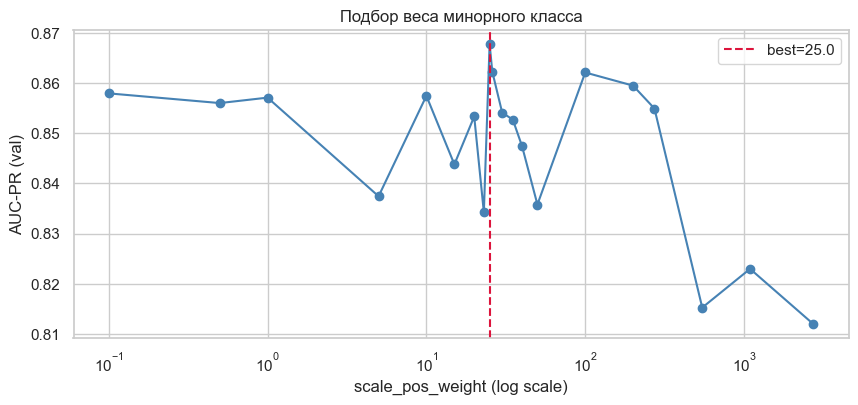

In [60]:
from sklearn.metrics import average_precision_score

weights = [0.1, 0.5, 1, 5, 10, 15, 20, 23, 25, 26, 30, 35, 40, 50, 100, 200,
           scale_pos_weight * 0.5,  
           scale_pos_weight,        
           scale_pos_weight * 2,     
           scale_pos_weight * 5]     

results = []

for w in tqdm(weights):
    model_w = CatBoostClassifier(
        iterations=1000,
        eval_metric='AUC',
        random_seed=42,
        verbose=0,
        scale_pos_weight=w
    )
    model_w.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    
    y_val_proba_w = model_w.predict_proba(X_val)[:, 1]
    auc_pr_val = average_precision_score(y_val, y_val_proba_w)
    
    results.append({
        'weight': w,
        'auc_pr': auc_pr_val,
        'model': model_w,
        'proba': y_val_proba_w
    })
    print(f"weight={w:>10.2f} | AUC-PR val: {auc_pr_val:.4f}")


best = max(results, key=lambda x: x['auc_pr'])
print(f"\nЛучший вес: {best['weight']:.2f} | AUC-PR val: {best['auc_pr']:.4f}")

best_thresh_w, _ = find_best_threshold(y_val.values, best['proba'], metric='mcc')

y_test_proba_best = best['model'].predict_proba(X_test)[:, 1]
y_test_pred_best = (y_test_proba_best >= best_thresh_w).astype(int)

print(f"Лучший порог (по MCC на val): {best_thresh_w:.4f}")
print("\nСравнение метрик на TEST")
print(f"{'Метрика':<12} {'Бейзлайн':>12} {'Best Weighted':>14}")
print(f"{'Accuracy':<12} {(y_test.values == y_test_pred).mean():>12.4%} {(y_test.values == y_test_pred_best).mean():>14.4%}")
print(f"{'Kappa':<12} {cohen_kappa(y_test.values, y_test_pred):>12.4f} {cohen_kappa(y_test.values, y_test_pred_best):>14.4f}")
print(f"{'MCC':<12} {mcc(y_test.values, y_test_pred):>12.4f} {mcc(y_test.values, y_test_pred_best):>14.4f}")
print(f"{'AUC-ROC':<12} {roc_auc_score(y_test, y_test_proba):>12.4f} {roc_auc_score(y_test, y_test_proba_best):>14.4f}")
print(f"{'AUC-PR':<12} {average_precision_score(y_test, y_test_proba):>12.4f} {average_precision_score(y_test, y_test_proba_best):>14.4f}")


plt.figure(figsize=(10, 4))
plt.plot([r['weight'] for r in results],
         [r['auc_pr'] for r in results], marker='o', color='steelblue')
plt.axvline(best['weight'], color='crimson', linestyle='--', 
            label=f"best={best['weight']:.1f}")
plt.xscale('log')
plt.xlabel('scale_pos_weight (log scale)')
plt.ylabel('AUC-PR (val)')
plt.title('Подбор веса минорного класса')
plt.legend()
plt.show()

> При больших весах модель становится слишком агрессивной в прогнозах. 

На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса. 

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [92]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Первый метод — SMOTE. Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берём точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем её в выборку.

In [73]:
from imblearn.over_sampling import SMOTE

Используем SMOTE для ресэмплинга обучающей выборки и обучим на ней модель (вес положительных объектов скалировать не нужно). Качество замеряем на тестовой выборке.

**Важно:** валидационную и тестовую выборки не преобразуем никак — отслеживать качество на объектах, которых в реальности не существует, бессмысленно.

Дальше сравним полное выравнивание выборки с частичным, когда баланс классов улучшается, но не достигает равенства (скажем, 1:2 и 1:10).

In [76]:
n_majority = (y_train == 0).sum()
n_minority = (y_train == 1).sum()
print(f"До SMOTE: majority={n_majority}, minority={n_minority}, ratio=1:{n_majority//n_minority}")

results_smote = []


sampling_strategies = {
    '1:10': n_majority // 10,   
    '1:2':  n_majority // 2,    
    '1:1':  n_majority,       
}

for name, n_minority_target in sampling_strategies.items():
    print(f"\n Баланс классов {name} (minority: {n_minority_target})")
    
    smote = SMOTE(
        sampling_strategy={1: n_minority_target},
        random_state=42
    )
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"После SMOTE: majority={( y_train_res==0).sum()}, minority={(y_train_res==1).sum()}")
    
    model_smote = CatBoostClassifier(
        iterations=1000,
        eval_metric='AUC',
        random_seed=42,
        verbose=0
    )

    model_smote.fit(
        X_train_res, y_train_res,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    
    y_val_proba_s = model_smote.predict_proba(X_val)[:, 1]
    y_test_proba_s = model_smote.predict_proba(X_test)[:, 1]
    
    best_thresh_s, _ = find_best_threshold(y_val.values, y_val_proba_s, metric='mcc')
    y_test_pred_s = (y_test_proba_s >= best_thresh_s).astype(int)
    
    results_smote.append({
        'name': name,
        'thresh': best_thresh_s,
        'kappa': cohen_kappa(y_test.values, y_test_pred_s),
        'mcc': mcc(y_test.values, y_test_pred_s),
        'roc_auc': roc_auc_score(y_test, y_test_proba_s),
        'pr_auc': average_precision_score(y_test, y_test_proba_s),
    })


print("\nСравнение метрик на TEST")
print(f"{'Метрика':<12} {'Бейзлайн':>10} ", end='')
for r in results_smote:
    print(f" {'SMOTE '+r['name']:>12}", end='')
print()


for metric, base_val, key in [
    ('Kappa', cohen_kappa(y_test.values, y_test_pred), 'kappa'),
    ('MCC', mcc(y_test.values, y_test_pred), 'mcc'),
    ('AUC-ROC', roc_auc_score(y_test, y_test_proba), 'roc_auc'),
    ('AUC-PR', average_precision_score(y_test, y_test_proba), 'pr_auc'),
]:
    print(f"{metric:<12} {base_val:>10.4f}", end='')
    for r in results_smote:
        print(f" {r[key]:>12.4f}", end='')
    print()

for r in results_smote:
    print(f"\nПорог SMOTE {r['name']}: {r['thresh']:.4f}")

До SMOTE: majority=227428, minority=417, ratio=1:545

 Баланс классов 1:10 (minority: 22742)
После SMOTE: majority=227428, minority=22742

 Баланс классов 1:2 (minority: 113714)
После SMOTE: majority=227428, minority=113714

 Баланс классов 1:1 (minority: 227428)
После SMOTE: majority=227428, minority=227428

Сравнение метрик на TEST
Метрика        Бейзлайн    SMOTE 1:10    SMOTE 1:2    SMOTE 1:1
Kappa            0.7315       0.6806       0.6380       0.6974
MCC              0.7335       0.6820       0.6393       0.6976
AUC-ROC          0.9560       0.9830       0.9830       0.9814
AUC-PR           0.7003       0.7137       0.6432       0.6410

Порог SMOTE 1:10: 0.7181

Порог SMOTE 1:2: 0.8485

Порог SMOTE 1:1: 0.9139


> Частичное выравнивание выборки помогло больше. Синтетических данных не должно быть много.

Для vanilla SMOTE существуют модификации, часть из которых реализована в библиотеке imblearn. Разберём их отдельно — ниже краткая формулировка идеи каждого метода.

BorderlineSMOTE - создает синтетические данные, используя только примеры на границе классов: тех, у которых среди k ближайших соседей много объектов мажорного класса. Идея: именно на границе классов модели сложнее всего, туда и добавляем синтетику. В то время как обычный SMOTE генерирует синтетику равномерно по всем minority-объектам.

SVM-SMOTE - использует SVM для нахождения опорных векторов минорного класса, то есть объектов, лежащих близко к границе решения. В их окрестностях далее генерируются синтетические объекты.

K-Means-SMOTE - сначала кластеризует всё признаковое пространство через K-Means, затем применяет SMOTE только в тех кластерах, у которых малая доля minority-объектов. Это помогает избежать генерации синтетики там, где мошенников в реальности нет.

ADASYN - генерирует больше синтетических объектов там, где minority-объекты труднее всего классифицировать. Количество синтетики адаптивно для каждого объекта, а не одинаково, в силу чего этот метод более гибкий по сравнению с Borderline.

Далее эти методы сравниваются между собой на исходных данных.

In [82]:
from imblearn.over_sampling import (
    SMOTE, BorderlineSMOTE, KMeansSMOTE, ADASYN
)

samplers = {
    'SMOTE': SMOTE(sampling_strategy={1: n_majority // 10}, random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(sampling_strategy={1: n_majority // 10}, random_state=42),
    'KMeans-SMOTE': KMeansSMOTE(
                                sampling_strategy={1: n_majority // 10},
                                random_state=42,
                                cluster_balance_threshold=0.001,  
                                kmeans_estimator=50,             
                       ),
    'ADASYN':          ADASYN(sampling_strategy=0.1, random_state=42),
}

results_over = []

for name, sampler in tqdm(samplers.items()):
    print(f"\n{name}")
    
    X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)

        
    print(f"minority={(y_train_res==1).sum()}, majority={(y_train_res==0).sum()}")
    
    model_s = CatBoostClassifier(
        iterations=1000,
        eval_metric='AUC',
        random_seed=42,
        verbose=0
    )
    model_s.fit(
        X_train_res, y_train_res,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    
    y_val_proba_s = model_s.predict_proba(X_val)[:, 1]
    y_test_proba_s = model_s.predict_proba(X_test)[:, 1]
    
    best_thresh_s, _ = find_best_threshold(y_val.values, y_val_proba_s, metric='mcc')
    y_test_pred_s = (y_test_proba_s >= best_thresh_s).astype(int)
    
    results_over.append({
        'name': name,
        'kappa': cohen_kappa(y_test.values, y_test_pred_s),
        'mcc': mcc(y_test.values, y_test_pred_s),
        'roc_auc': roc_auc_score(y_test, y_test_proba_s),
        'pr_auc': average_precision_score(y_test, y_test_proba_s),
        'thresh': best_thresh_s,
    })



header = f"{'Метрика':<12} {'Бейзлайн':>10}"
for r in results_over:
    header += f" {r['name']:>16}"
print(f"\n{header}")


for metric, base_val, key in [
    ('Kappa', cohen_kappa(y_test.values, y_test_pred), 'kappa'),
    ('MCC', mcc(y_test.values, y_test_pred), 'mcc'),
    ('AUC-ROC', roc_auc_score(y_test, y_test_proba), 'roc_auc'),
    ('AUC-PR', average_precision_score(y_test, y_test_proba), 'pr_auc'),
]:
    row = f"{metric:<12} {base_val:>10.4f}"
    for r in results_over:
        row += f" {r[key]:>16.4f}"
    print(row)

for r in results_over:
    print(f"Порог {r['name']}: {r['thresh']:.4f}")

  0%|          | 0/4 [00:00<?, ?it/s]


SMOTE
minority=22742, majority=227428

BorderlineSMOTE
minority=22742, majority=227428

KMeans-SMOTE
minority=22765, majority=227428

ADASYN
minority=22698, majority=227428

Метрика        Бейзлайн            SMOTE  BorderlineSMOTE     KMeans-SMOTE           ADASYN
Kappa            0.7315           0.6806           0.6954           0.7315           0.7141
MCC              0.7335           0.6820           0.6961           0.7335           0.7149
AUC-ROC          0.9560           0.9830           0.9559           0.9739           0.9623
AUC-PR           0.7003           0.7137           0.7217           0.6771           0.7003
Порог SMOTE: 0.7181
Порог BorderlineSMOTE: 0.5762
Порог KMeans-SMOTE: 0.2848
Порог ADASYN: 0.8434


BorderlineSMOTE лучший по AUC-PR (0.722) - фокус на граничных объектах действительно помогает точнее определять мошенников.

In [85]:
from imblearn.over_sampling import SVMSMOTE
import time

best_svm_result = None
all_svm_results = []

for n_subsample in [1600, 1800, 2000]:
    for seed in [42, 123, 456, 789, 1337]:
        print(f"n_subsample={n_subsample} | seed={seed}")
        
        idx_min = np.where(y_train == 1)[0]
        idx_maj = np.where(y_train == 0)[0]
        idx_maj_sub = np.random.RandomState(seed).choice(idx_maj, size=n_subsample, replace=False)
        
        idx_sub = np.concatenate([idx_min, idx_maj_sub])
        X_train_sub = X_train.iloc[idx_sub]
        y_train_sub = y_train.iloc[idx_sub]
        
        t0 = time.time()
        svm_smote = SVMSMOTE(
            sampling_strategy={1: n_majority // 10},
            random_state=seed,
            m_neighbors=10,
            k_neighbors=10,
        )
        X_svm_res, y_svm_res = svm_smote.fit_resample(X_train_sub, y_train_sub)
        print(f"Ресэмплинг: {time.time()-t0:.1f}с | "
              f"minority={(y_svm_res==1).sum()}, majority={(y_svm_res==0).sum()}")
        
        idx_maj_rest = np.setdiff1d(idx_maj, idx_maj_sub)
        X_svm_full = pd.concat([
            pd.DataFrame(X_svm_res, columns=X_train.columns),
            X_train.iloc[idx_maj_rest]
        ], ignore_index=True)
        y_svm_full = pd.concat([
            pd.Series(y_svm_res),
            y_train.iloc[idx_maj_rest]
        ], ignore_index=True)
        
        t0 = time.time()
        model_svm = CatBoostClassifier(
            iterations=2000,
            eval_metric='AUC',
            random_seed=seed,
            verbose=0,
            early_stopping_rounds=100,
        )
        model_svm.fit(X_svm_full, y_svm_full, eval_set=(X_val, y_val))
        print(f"Обучение: {time.time()-t0:.1f}с | итераций: {model_svm.best_iteration_}")
        
        y_val_proba_svm = model_svm.predict_proba(X_val)[:, 1]
        y_test_proba_svm = model_svm.predict_proba(X_test)[:, 1]
        
        best_thresh_svm, _ = find_best_threshold(y_val.values, y_val_proba_svm, metric='mcc')
        y_test_pred_svm = (y_test_proba_svm >= best_thresh_svm).astype(int)
        
        pr_auc = average_precision_score(y_test, y_test_proba_svm)
        mcc_val = mcc(y_test.values, y_test_pred_svm)
        kappa = cohen_kappa(y_test.values, y_test_pred_svm)
        roc_auc = roc_auc_score(y_test, y_test_proba_svm)
        
        print(f"Порог: {best_thresh_svm:.4f} | MCC: {mcc_val:.4f} | AUC-PR: {pr_auc:.4f}")
        
        all_svm_results.append({
            'n_subsample': n_subsample,
            'seed': seed,
            'iters': model_svm.best_iteration_,
            'kappa': kappa,
            'mcc': mcc_val,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
        })
        
        if best_svm_result is None or pr_auc > best_svm_result['pr_auc']:
            best_svm_result = all_svm_results[-1]

print(f"Лучший SVM-SMOTE: n_subsample={best_svm_result['n_subsample']}, seed={best_svm_result['seed']}")
print(f"Kappa: {best_svm_result['kappa']:.4f}")
print(f"MCC: {best_svm_result['mcc']:.4f}")
print(f"AUC-ROC: {best_svm_result['roc_auc']:.4f}")
print(f"AUC-PR: {best_svm_result['pr_auc']:.4f}")

n_subsample=1600 | seed=42
Ресэмплинг: 0.1с | minority=22742, majority=1600
Обучение: 2.7с | итераций: 37
Порог: 0.9568 | MCC: 0.7460 | AUC-PR: 0.7196
n_subsample=1600 | seed=123
Ресэмплинг: 0.1с | minority=22742, majority=1600
Обучение: 2.2с | итераций: 12
Порог: 0.8637 | MCC: 0.7271 | AUC-PR: 0.6848
n_subsample=1600 | seed=456
Ресэмплинг: 0.1с | minority=22742, majority=1600
Обучение: 2.4с | итераций: 24
Порог: 0.8058 | MCC: 0.6961 | AUC-PR: 0.7057
n_subsample=1600 | seed=789
Ресэмплинг: 0.1с | minority=22742, majority=1600
Обучение: 2.1с | итераций: 4
Порог: 0.7825 | MCC: 0.7149 | AUC-PR: 0.6677
n_subsample=1600 | seed=1337
Ресэмплинг: 0.1с | minority=22742, majority=1600
Обучение: 2.7с | итераций: 31
Порог: 0.8790 | MCC: 0.7271 | AUC-PR: 0.7007
n_subsample=1800 | seed=42
Ресэмплинг: 0.1с | minority=22742, majority=1800
Обучение: 2.0с | итераций: 1
Порог: 0.5984 | MCC: 0.7442 | AUC-PR: 0.6272
n_subsample=1800 | seed=123
Ресэмплинг: 0.1с | minority=22742, majority=1800
Обучение: 2.4с

> svm-smote лучше справился, но очень нестабилен

До этого момента все решения концентрировались на работе с минорным классом. Теперь зайдём с другой стороны: возможно, для восстановления закономерностей столько объектов мажорного класса не нужно, и они просто засоряют выборку.

Для этого существуют методы андерсэмплинга. Самое простое — удалять точки мажорного класса, пока не получится приемлемый баланс. Протестируем такой метод и построим графики достигаемых значений метрик в зависимости от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [90]:
from imblearn.under_sampling import RandomUnderSampler

Исходный train: majority=227428, minority=417


  0%|          | 0/7 [00:00<?, ?it/s]

   1:1 | n_total=    834 | фактическое соотношение 1:1.0 | balance=0.500 | size_ratio=0.0037
       MCC=0.7111 | AUC-PR=0.6980
   1:2 | n_total=   1251 | фактическое соотношение 1:2.0 | balance=0.333 | size_ratio=0.0055
       MCC=0.7033 | AUC-PR=0.6861
   1:5 | n_total=   2502 | фактическое соотношение 1:5.0 | balance=0.167 | size_ratio=0.0110
       MCC=0.6816 | AUC-PR=0.6876
  1:10 | n_total=   4587 | фактическое соотношение 1:10.0 | balance=0.091 | size_ratio=0.0201
       MCC=0.6225 | AUC-PR=0.6693
  1:20 | n_total=   8757 | фактическое соотношение 1:20.0 | balance=0.048 | size_ratio=0.0384
       MCC=0.6511 | AUC-PR=0.6530
  1:50 | n_total=  21267 | фактическое соотношение 1:50.0 | balance=0.020 | size_ratio=0.0933
       MCC=0.7237 | AUC-PR=0.6900
 1:100 | n_total=  42117 | фактическое соотношение 1:100.0 | balance=0.010 | size_ratio=0.1848
       MCC=0.7155 | AUC-PR=0.6600
Сравнение метрик на TEST
Метрика        Бейзлайн      1:1      1:2      1:5     1:10     1:20     1:50    

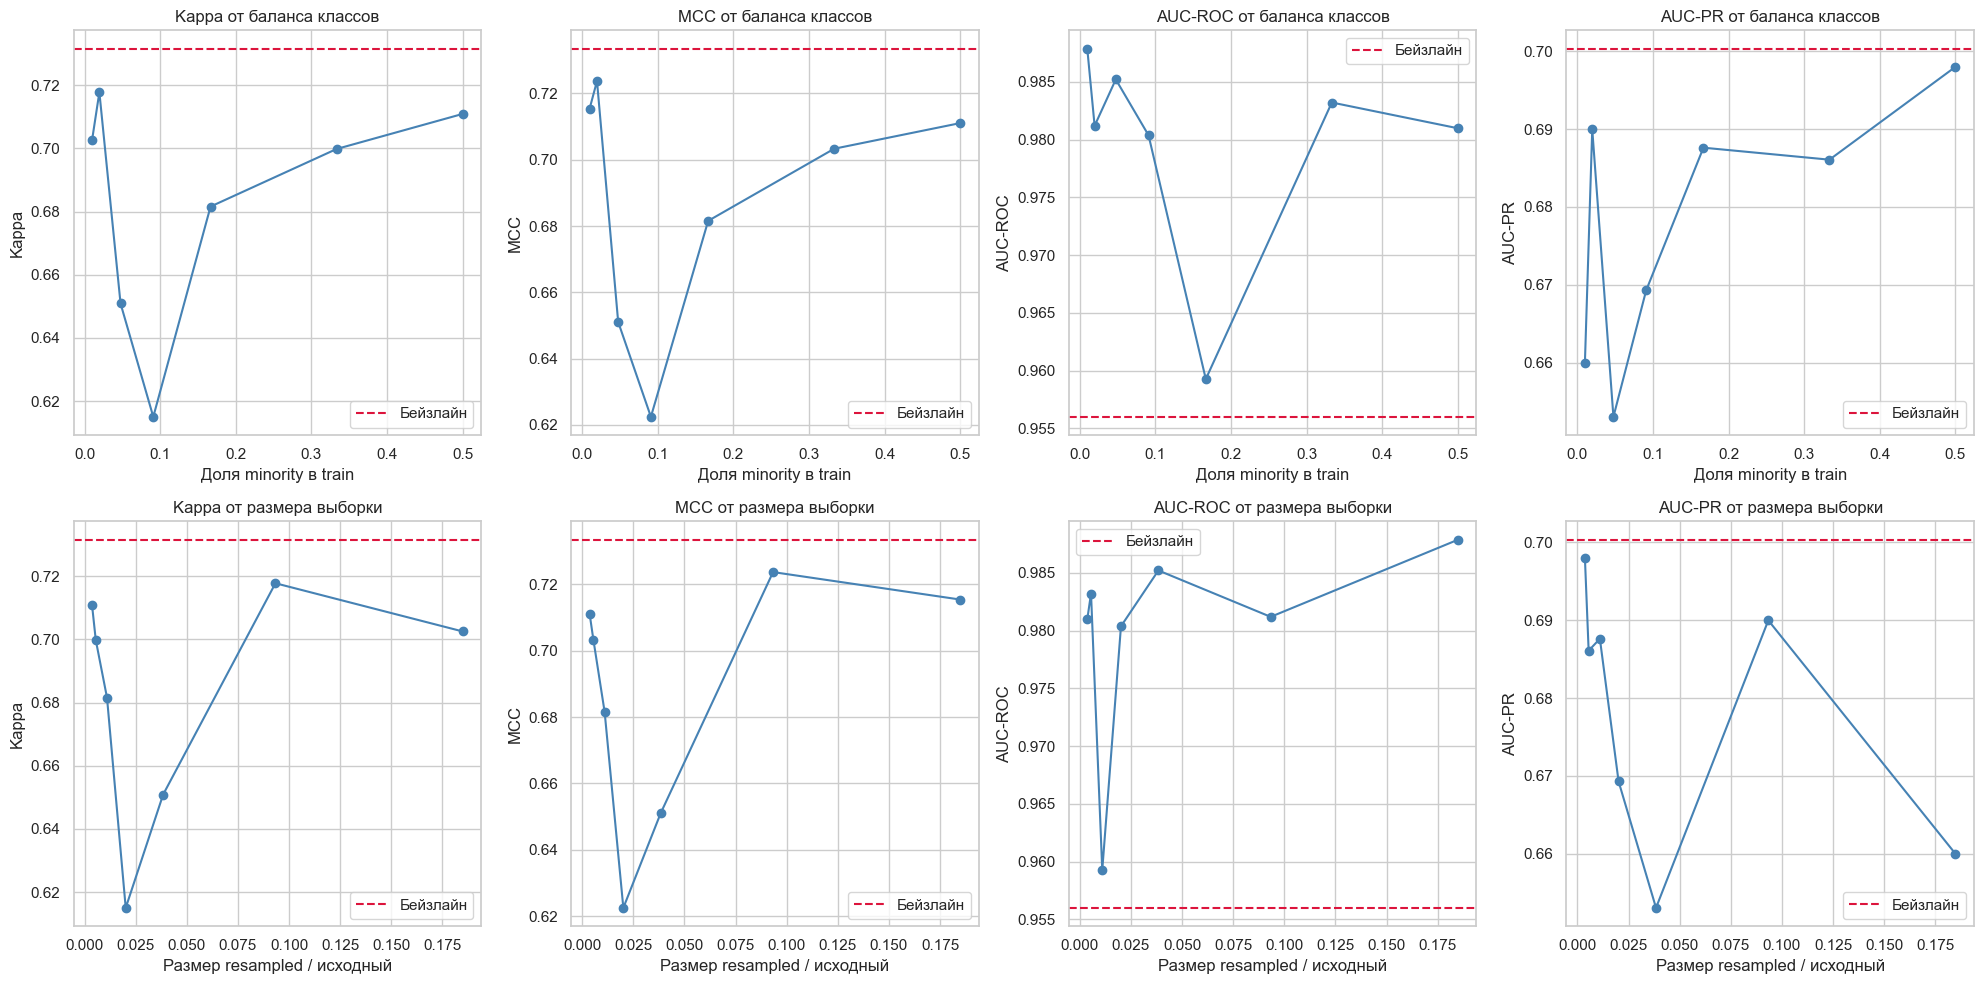

In [92]:
n_minority_train = (y_train == 1).sum()  
n_majority_train = (y_train == 0).sum() 

print(f"Исходный train: majority={n_majority_train}, minority={n_minority_train}")


ratios = {
    '1:1': n_minority_train * 1,
    '1:2': n_minority_train * 2,
    '1:5': n_minority_train * 5,
    '1:10': n_minority_train * 10,
    '1:20': n_minority_train * 20,
    '1:50': n_minority_train * 50,
    '1:100': n_minority_train * 100,
}

results_under = []

for name, n_majority_target in tqdm(ratios.items()):
    n_majority_target = int(np.clip(
        n_majority_target,
        n_minority_train,   
        n_majority_train    
    ))
    
    rus = RandomUnderSampler(
        sampling_strategy={0: n_majority_target},
        random_state=42
    )
    X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
    
    n_total_res = len(y_train_res)
    balance = (y_train_res == 1).mean()
    size_ratio = n_total_res / len(y_train)
    
    assert size_ratio <= 1.0, f"size_ratio > 1 для {name}"
    
    print(f"{name:>6} | n_total={n_total_res:>7} | "
          f"фактическое соотношение 1:{n_majority_target/n_minority_train:.1f} | "
          f"balance={balance:.3f} | size_ratio={size_ratio:.4f}")
    
    model_rus = CatBoostClassifier(
        iterations=1000,
        eval_metric='AUC',
        random_seed=42,
        verbose=0
    )
    model_rus.fit(
        X_train_res, y_train_res,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    
    y_val_proba_rus = model_rus.predict_proba(X_val)[:, 1]
    y_test_proba_rus = model_rus.predict_proba(X_test)[:, 1]
    
    best_thresh_rus, _ = find_best_threshold(y_val.values, y_val_proba_rus, metric='mcc')
    y_test_pred_rus = (y_test_proba_rus >= best_thresh_rus).astype(int)
    
    results_under.append({
        'name': name,
        'n_majority': n_majority_target,
        'n_total': n_total_res,
        'size_ratio': size_ratio,
        'balance': balance,
        'kappa': cohen_kappa(y_test.values, y_test_pred_rus),
        'mcc': mcc(y_test.values, y_test_pred_rus),
        'roc_auc': roc_auc_score(y_test, y_test_proba_rus),
        'pr_auc': average_precision_score(y_test, y_test_proba_rus),
        'thresh': best_thresh_rus,
    })
    print(f"       MCC={results_under[-1]['mcc']:.4f} | AUC-PR={results_under[-1]['pr_auc']:.4f}")


base_metrics = {
    'kappa': cohen_kappa(y_test.values, y_test_pred),
    'mcc': mcc(y_test.values, y_test_pred),
    'roc_auc': roc_auc_score(y_test, y_test_proba),
    'pr_auc': average_precision_score(y_test, y_test_proba),
}


print("Сравнение метрик на TEST")
print(f"{'Метрика':<12} {'Бейзлайн':>10}", end='')
for r in results_under:
    print(f" {r['name']:>8}", end='')
print()


for metric, key in [('Kappa','kappa'), ('MCC','mcc'), ('AUC-ROC','roc_auc'), ('AUC-PR','pr_auc')]:
    print(f"{metric:<12} {base_metrics[key]:>10.4f}", end='')
    for r in results_under:
        print(f" {r[key]:>8.4f}", end='')
    print()


fig, axes = plt.subplots(2, 4, figsize=(20, 10))

metrics_plot = [
    ('kappa', 'Kappa'),
    ('mcc', 'MCC'),
    ('roc_auc', 'AUC-ROC'),
    ('pr_auc', 'AUC-PR'),
]

balances = [r['balance']    for r in results_under]
size_ratios = [r['size_ratio'] for r in results_under]

for i, (key, label) in enumerate(metrics_plot):
    vals = [r[key] for r in results_under]
    

    axes[0, i].plot(balances, vals, marker='o', color='steelblue')
    axes[0, i].axhline(y=base_metrics[key], color='crimson',
                       linestyle='--', label='Бейзлайн')
    axes[0, i].set_title(f'{label} от баланса классов')
    axes[0, i].set_xlabel('Доля minority в train')
    axes[0, i].set_ylabel(label)
    axes[0, i].legend()
    

    axes[1, i].plot(size_ratios, vals, marker='o', color='steelblue')
    axes[1, i].axhline(y=base_metrics[key], color='crimson',
                       linestyle='--', label='Бейзлайн')
    axes[1, i].set_title(f'{label} от размера выборки')
    axes[1, i].set_xlabel('Размер resampled / исходный')
    axes[1, i].set_ylabel(label)
    axes[1, i].legend()

plt.tight_layout()
plt.show()

> Модель на меньшей выборке лучше разделяет классы в целом, но хуже работает именно на мошенниках. Подтверждает, что AUC-ROC обманчив при дисбалансе.

Даже такой наивный подход даёт неплохой результат и улучшает метрики. Но информацию о распределении объектов в выборке он никак не использует, а даже относительно простые эвристики заметно поднимают качество. Например, при отбрасывании можно учитывать близость объектов мажорного класса к минорному и удалять самые близкие. Протестируем алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) и построим графики, аналогичные предыдущему пункту, добавив зависимость качества от числа соседей.

In [96]:
from imblearn.under_sampling import NearMiss
import warnings

n_minority_train = (y_train == 1).sum()
n_majority_train = (y_train == 0).sum()

ratios = {
    '1:1': n_minority_train * 1,
    '1:2': n_minority_train * 2,
    '1:5': n_minority_train * 5,
    '1:10': n_minority_train * 10,
    '1:20': n_minority_train * 20,
    '1:50': n_minority_train * 50,
    '1:100': n_minority_train * 100,
}

versions = [1, 2, 3]
n_neighbors_list = [3, 5, 10]
n3_fixed = 100 

results_nm = []
base_metrics = {
    'kappa': cohen_kappa(y_test.values, y_test_pred),
    'mcc': mcc(y_test.values, y_test_pred),
    'roc_auc': roc_auc_score(y_test, y_test_proba),
    'pr_auc': average_precision_score(y_test, y_test_proba),
}

for version in versions:
    for n_neighbors in tqdm(n_neighbors_list, desc=f'NearMiss v{version}'):
        for name, n_majority_target in ratios.items():

            n_majority_target = int(np.clip(
                n_majority_target,
                n_minority_train,
                n_majority_train
            ))

            if version == 3:
                nm = NearMiss(
                    version=3,
                    n_neighbors=n_neighbors,
                    n_neighbors_ver3=n3_fixed,
                    sampling_strategy={0: n_majority_target}
                )
            else:
                nm = NearMiss(
                    version=version,
                    n_neighbors=n_neighbors,
                    sampling_strategy={0: n_majority_target}
                )

            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                X_train_res, y_train_res = nm.fit_resample(X_train, y_train)

            actual_balance = (y_train_res == 1).mean()
            expected_balance = n_minority_train / (n_minority_train + n_majority_target)
            tolerance = max(0.05, expected_balance * 0.5)

            if abs(actual_balance - expected_balance) > tolerance:
                print(f"v{version} k={n_neighbors} {name}: "
                      f"баланс не достигнут "
                      f"({actual_balance:.3f} vs {expected_balance:.3f}) — пропуск")
                continue

            n_total_res = len(y_train_res)
            size_ratio  = n_total_res / len(y_train)

            model_nm = CatBoostClassifier(
                iterations=1000,
                eval_metric='AUC',
                random_seed=42,
                verbose=0
            )
            model_nm.fit(
                X_train_res, y_train_res,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50
            )

            y_val_proba_nm  = model_nm.predict_proba(X_val)[:, 1]
            y_test_proba_nm = model_nm.predict_proba(X_test)[:, 1]

            best_thresh_nm, _ = find_best_threshold(
                y_val.values, y_val_proba_nm, metric='mcc'
            )
            y_test_pred_nm = (y_test_proba_nm >= best_thresh_nm).astype(int)

            results_nm.append({
                'version': version,
                'n_neighbors': n_neighbors,
                'n3': n3_fixed if version == 3 else None,
                'ratio': name,
                'n_total': n_total_res,
                'size_ratio': size_ratio,
                'balance': actual_balance,
                'kappa': cohen_kappa(y_test.values, y_test_pred_nm),
                'mcc': mcc(y_test.values, y_test_pred_nm),
                'roc_auc': roc_auc_score(y_test, y_test_proba_nm),
                'pr_auc': average_precision_score(y_test, y_test_proba_nm),
            })
            print(f"v{version} k={n_neighbors} {name:>6} | "
                  f"balance={actual_balance:.3f}  | "
                  f"MCC={results_nm[-1]['mcc']:.4f} | "
                  f"AUC-PR={results_nm[-1]['pr_auc']:.4f}")

NearMiss v1:   0%|          | 0/3 [00:00<?, ?it/s]

v1 k=3    1:1 | balance=0.500  | MCC=0.6045 | AUC-PR=0.6530
v1 k=3    1:2 | balance=0.333  | MCC=0.7033 | AUC-PR=0.6164
v1 k=3    1:5 | balance=0.167  | MCC=0.6927 | AUC-PR=0.6191
v1 k=3   1:10 | balance=0.091  | MCC=0.6845 | AUC-PR=0.6084
v1 k=3   1:20 | balance=0.048  | MCC=0.7384 | AUC-PR=0.7196
v1 k=3   1:50 | balance=0.020  | MCC=0.4902 | AUC-PR=0.5837
v1 k=3  1:100 | balance=0.010  | MCC=0.6845 | AUC-PR=0.6002
v1 k=5    1:1 | balance=0.500  | MCC=0.7155 | AUC-PR=0.6311
v1 k=5    1:2 | balance=0.333  | MCC=0.7384 | AUC-PR=0.5975
v1 k=5    1:5 | balance=0.167  | MCC=0.7384 | AUC-PR=0.6361
v1 k=5   1:10 | balance=0.091  | MCC=0.6927 | AUC-PR=0.6484
v1 k=5   1:20 | balance=0.048  | MCC=0.4140 | AUC-PR=0.4304
v1 k=5   1:50 | balance=0.020  | MCC=0.6394 | AUC-PR=0.5148
v1 k=5  1:100 | balance=0.010  | MCC=0.6153 | AUC-PR=0.5664
v1 k=10    1:1 | balance=0.500  | MCC=0.6203 | AUC-PR=0.5753
v1 k=10    1:2 | balance=0.333  | MCC=0.5911 | AUC-PR=0.4127
v1 k=10    1:5 | balance=0.167  | MCC=

NearMiss v2:   0%|          | 0/3 [00:00<?, ?it/s]

v2 k=3    1:1 | balance=0.500  | MCC=0.7033 | AUC-PR=0.6811
v2 k=3    1:2 | balance=0.333  | MCC=0.7384 | AUC-PR=0.6178
v2 k=3    1:5 | balance=0.167  | MCC=0.6845 | AUC-PR=0.6994
v2 k=3   1:10 | balance=0.091  | MCC=0.7755 | AUC-PR=0.6699
v2 k=3   1:20 | balance=0.048  | MCC=0.6395 | AUC-PR=0.5809
v2 k=3   1:50 | balance=0.020  | MCC=0.5113 | AUC-PR=0.3421
v2 k=3  1:100 | balance=0.010  | MCC=0.7384 | AUC-PR=0.6239
v2 k=5    1:1 | balance=0.500  | MCC=0.7155 | AUC-PR=0.6536
v2 k=5    1:2 | balance=0.333  | MCC=0.5906 | AUC-PR=0.6158
v2 k=5    1:5 | balance=0.167  | MCC=0.7406 | AUC-PR=0.6683
v2 k=5   1:10 | balance=0.091  | MCC=0.7406 | AUC-PR=0.6470
v2 k=5   1:20 | balance=0.048  | MCC=0.4921 | AUC-PR=0.5336
v2 k=5   1:50 | balance=0.020  | MCC=0.5783 | AUC-PR=0.3300
v2 k=5  1:100 | balance=0.010  | MCC=0.3689 | AUC-PR=0.3143
v2 k=10    1:1 | balance=0.500  | MCC=0.7406 | AUC-PR=0.6438
v2 k=10    1:2 | balance=0.333  | MCC=0.7755 | AUC-PR=0.6744
v2 k=10    1:5 | balance=0.167  | MCC=

NearMiss v3:   0%|          | 0/3 [00:00<?, ?it/s]

v3 k=3    1:1 | balance=0.500  | MCC=0.7406 | AUC-PR=0.6172
v3 k=3    1:2 | balance=0.333  | MCC=0.7033 | AUC-PR=0.6542
v3 k=3    1:5 | balance=0.167  | MCC=0.5654 | AUC-PR=0.5690
v3 k=3   1:10 | balance=0.091  | MCC=0.5525 | AUC-PR=0.6094
v3 k=3   1:20 | balance=0.048  | MCC=0.6203 | AUC-PR=0.6647
v3 k=3   1:50 | balance=0.020  | MCC=0.7149 | AUC-PR=0.6938
v3 k=3  1:100 | balance=0.019  | MCC=0.6976 | AUC-PR=0.6896
v3 k=5    1:1 | balance=0.500  | MCC=0.7155 | AUC-PR=0.6130
v3 k=5    1:2 | balance=0.333  | MCC=0.6672 | AUC-PR=0.6538
v3 k=5    1:5 | balance=0.167  | MCC=0.6045 | AUC-PR=0.6331
v3 k=5   1:10 | balance=0.091  | MCC=0.8039 | AUC-PR=0.6904
v3 k=5   1:20 | balance=0.048  | MCC=0.4519 | AUC-PR=0.5639
v3 k=5   1:50 | balance=0.020  | MCC=0.7271 | AUC-PR=0.6993
v3 k=5  1:100 | balance=0.019  | MCC=0.6720 | AUC-PR=0.6307
v3 k=10    1:1 | balance=0.500  | MCC=0.7406 | AUC-PR=0.5987
v3 k=10    1:2 | balance=0.333  | MCC=0.6066 | AUC-PR=0.5267
v3 k=10    1:5 | balance=0.167  | MCC=

на малом количестве соседей в целом работает лучше

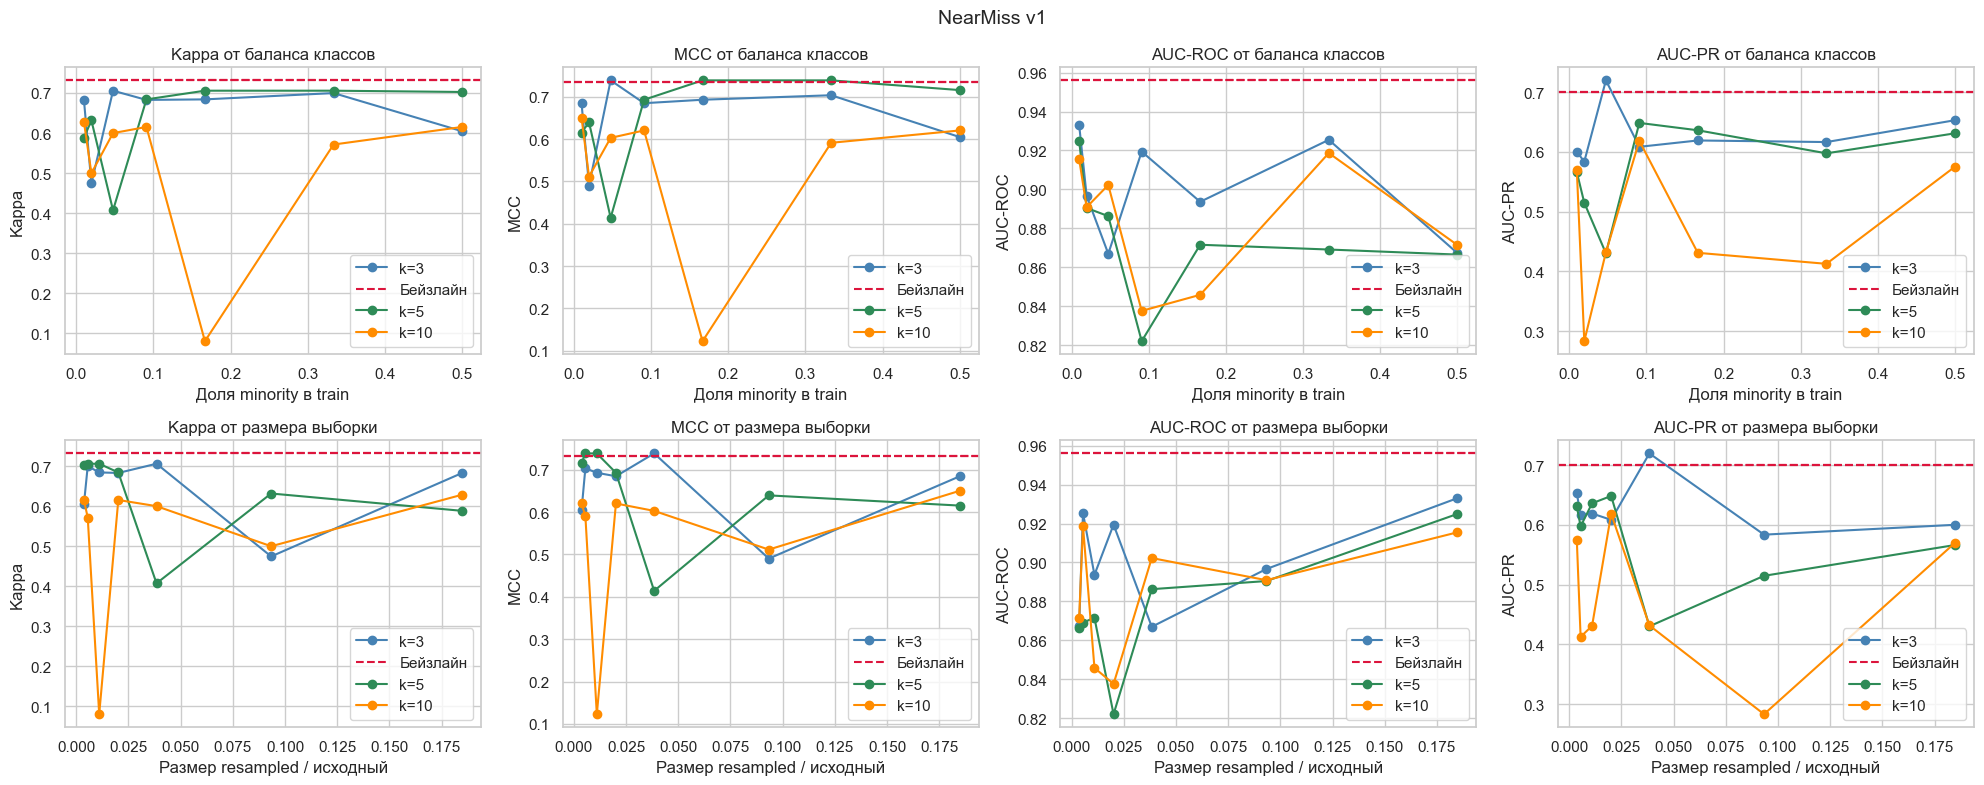

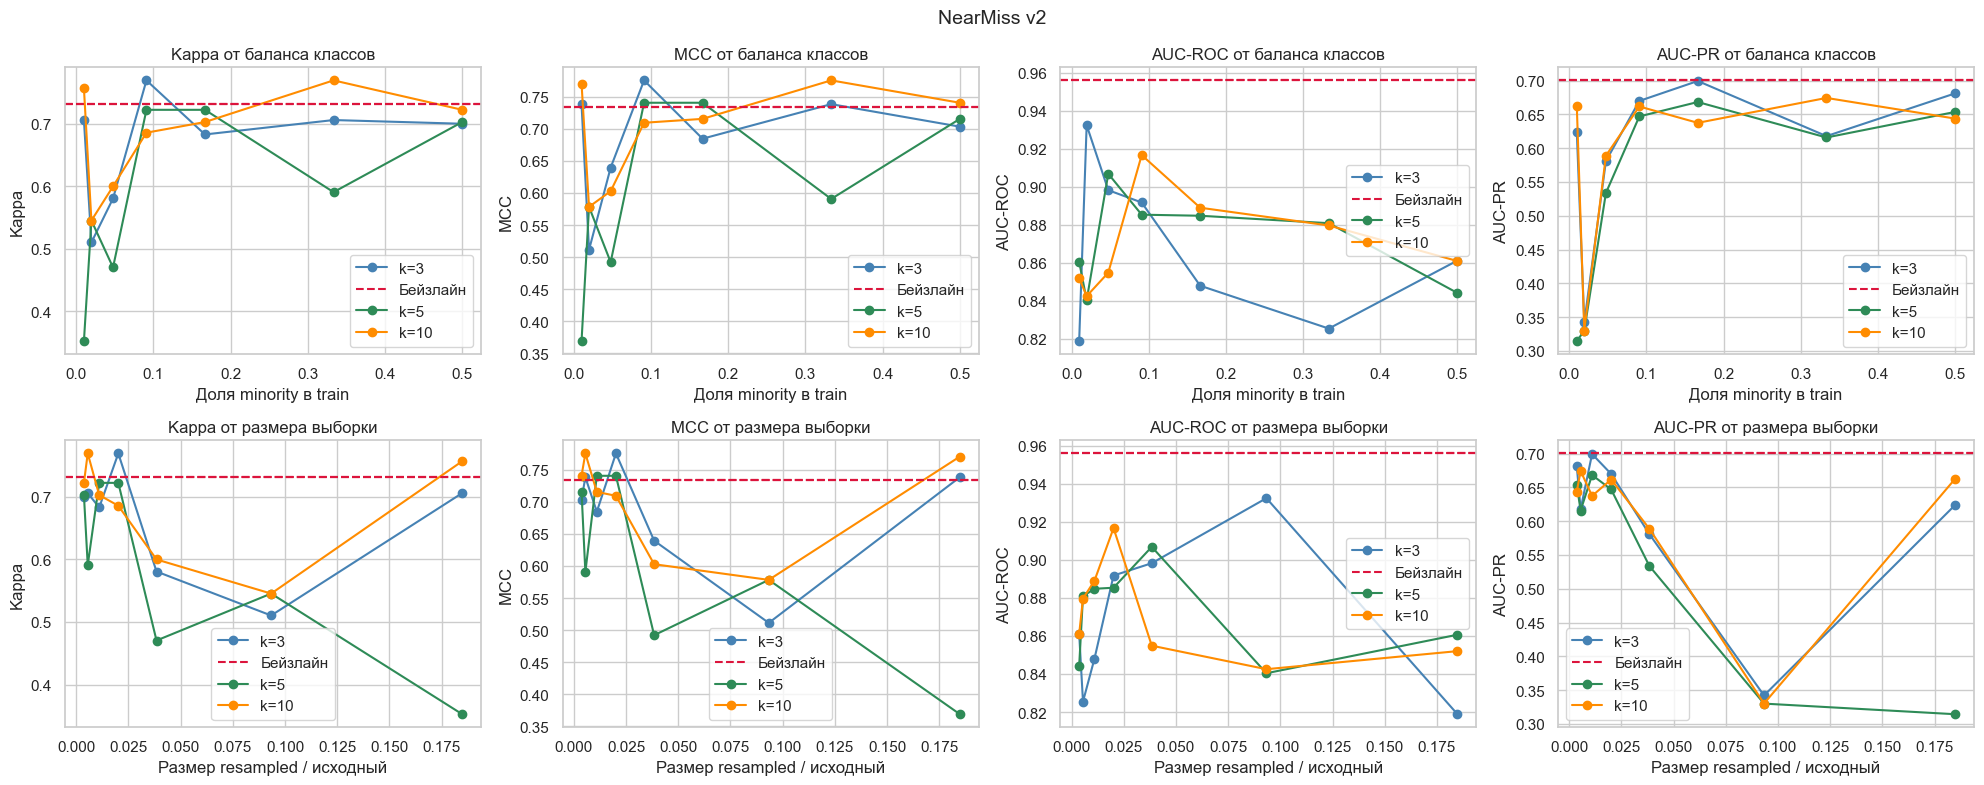

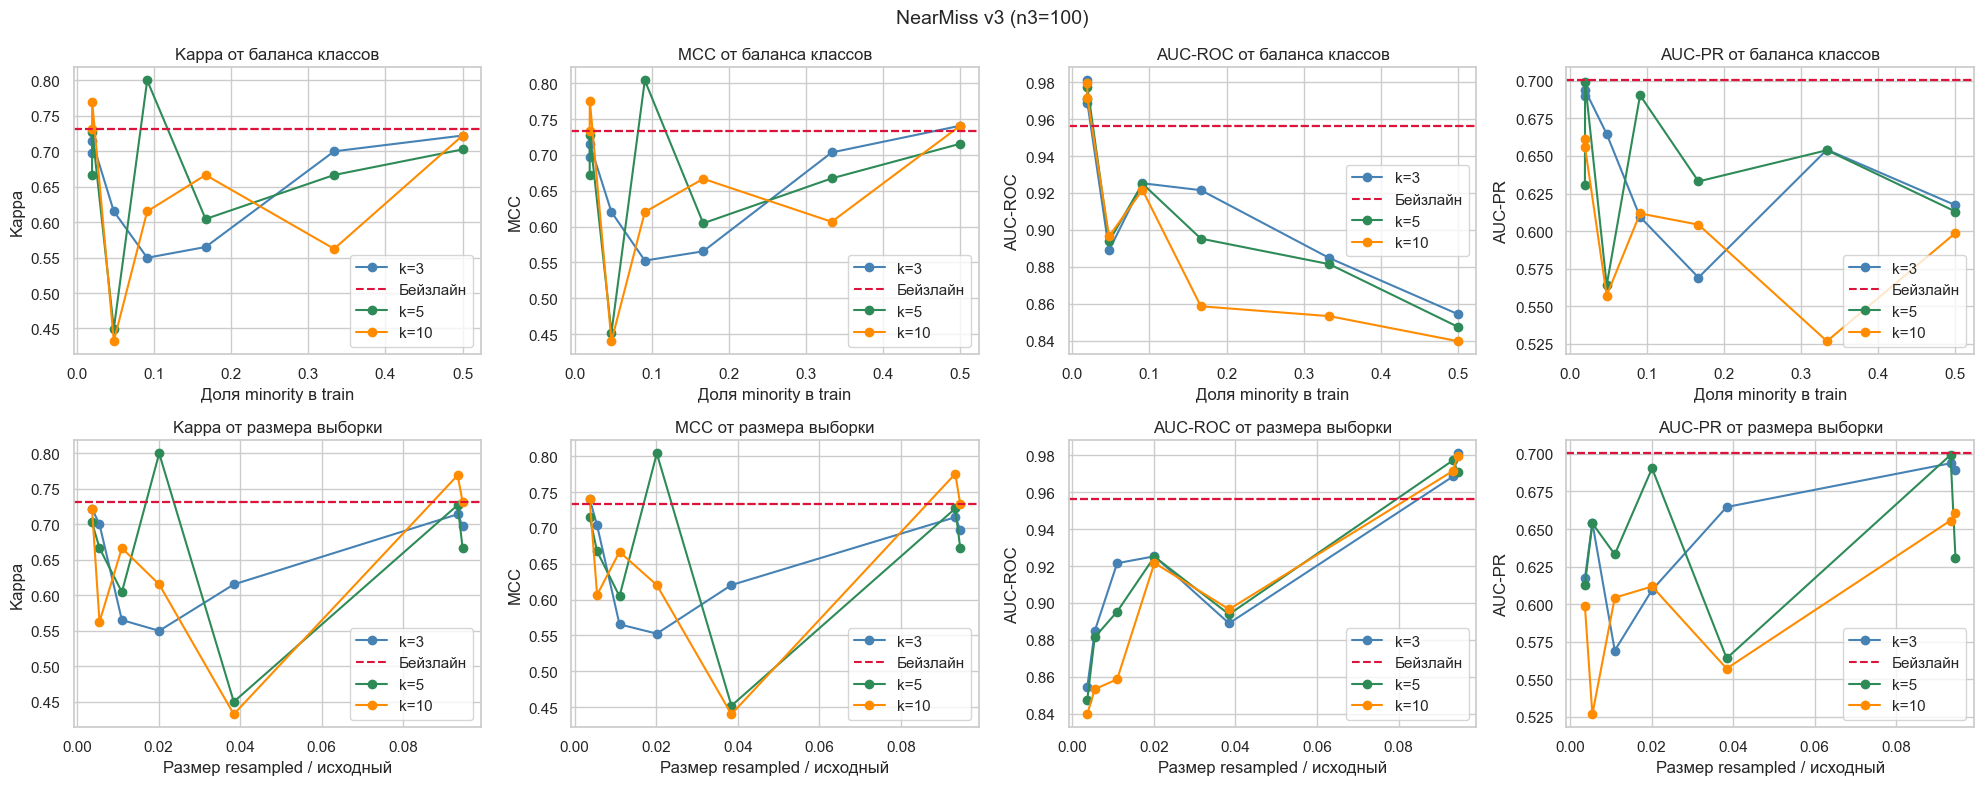

In [99]:
for version in versions:
    subset = [r for r in results_nm if r['version'] == version]
    if not subset:
        continue

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(
        f'NearMiss v{version}' + (f' (n3={n3_fixed})' if version == 3 else ''),
        fontsize=14
    )

    for n_neighbors, color in zip(
        n_neighbors_list, ['steelblue', 'seagreen', 'darkorange']
    ):
        sub_k = sorted(
            [r for r in subset if r['n_neighbors'] == n_neighbors],
            key=lambda x: x['balance']
        )
        if not sub_k:
            continue

        balances = [r['balance']    for r in sub_k]
        size_ratios = [r['size_ratio'] for r in sub_k]

        for i, (key, label) in enumerate([
            ('kappa', 'Kappa'),
            ('mcc', 'MCC'),
            ('roc_auc', 'AUC-ROC'),
            ('pr_auc',  'AUC-PR'),
        ]):
            vals = [r[key] for r in sub_k]

            axes[0, i].plot(balances, vals, marker='o', color=color,
                            label=f'k={n_neighbors}')
            axes[0, i].axhline(y=base_metrics[key], color='crimson',
                               linestyle='--',
                               label='Бейзлайн' if n_neighbors == 3 else '')
            axes[0, i].set_title(f'{label} от баланса классов')
            axes[0, i].set_xlabel('Доля minority в train')
            axes[0, i].set_ylabel(label)
            axes[0, i].legend()

            axes[1, i].plot(size_ratios, vals, marker='o', color=color,
                            label=f'k={n_neighbors}')
            axes[1, i].axhline(y=base_metrics[key], color='crimson',
                               linestyle='--',
                               label='Бейзлайн' if n_neighbors == 3 else '')
            axes[1, i].set_title(f'{label} от размера выборки')
            axes[1, i].set_xlabel('Размер resampled / исходный')
            axes[1, i].set_ylabel(label)
            axes[1, i].legend()

    plt.tight_layout()
    plt.show()

> k=5 для NearMiss v3 при balance 0.05 даёт MCC=0.804 выше бейзлайна. Оказалось выгодным удалять дальние majority из окрестностей minority.

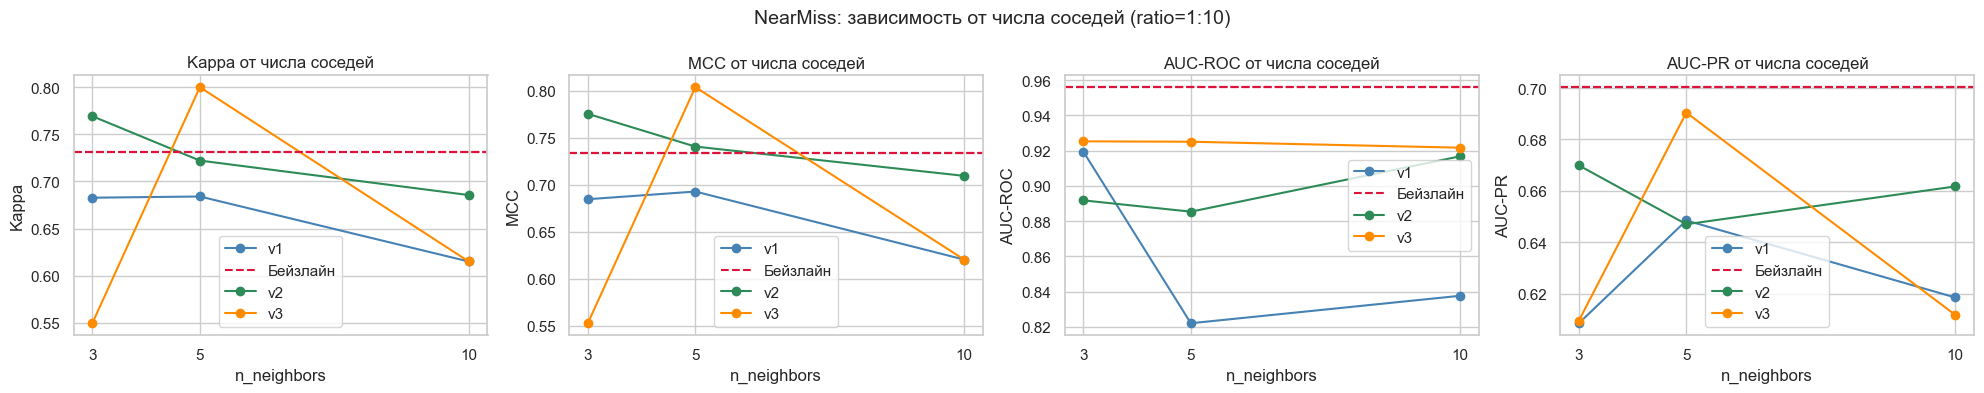


Лучший NearMiss: v1 k=3 n3=None ratio=1:20
Kappa: 0.7057
MCC: 0.7384
AUC-ROC:0.8670
AUC-PR: 0.7196


In [103]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('NearMiss: зависимость от числа соседей (ratio=1:10)', fontsize=14)

for version, color in zip(versions, ['steelblue', 'seagreen', 'darkorange']):
    sub = [r for r in results_nm
           if r['version'] == version and r['ratio'] == '1:10']

    sub = sorted(sub, key=lambda x: x['n_neighbors'])
    if not sub:
        continue

    ks = [r['n_neighbors'] for r in sub]
    for i, (key, label) in enumerate([
        ('kappa',   'Kappa'),
        ('mcc',     'MCC'),
        ('roc_auc', 'AUC-ROC'),
        ('pr_auc',  'AUC-PR'),
    ]):
        vals = [r[key] for r in sub]
        axes[i].plot(ks, vals, marker='o', color=color, label=f'v{version}')
        axes[i].axhline(y=base_metrics[key], color='crimson',
                        linestyle='--',
                        label='Бейзлайн' if version == 1 else '')
        axes[i].set_title(f'{label} от числа соседей')
        axes[i].set_xlabel('n_neighbors')
        axes[i].set_ylabel(label)
        axes[i].set_xticks(n_neighbors_list)
        axes[i].legend()

plt.tight_layout()
plt.show()

if results_nm:
    best_nm = max(results_nm, key=lambda x: x['pr_auc'])
    print(f"\nЛучший NearMiss: v{best_nm['version']} "
          f"k={best_nm['n_neighbors']} "
          f"n3={best_nm['n3']} "
          f"ratio={best_nm['ratio']}")
    print(f"Kappa: {best_nm['kappa']:.4f}")
    print(f"MCC: {best_nm['mcc']:.4f}")
    print(f"AUC-ROC:{best_nm['roc_auc']:.4f}")
    print(f"AUC-PR: {best_nm['pr_auc']:.4f}")

> v1 k=3 ratio=1:20 удаляет majority прямо на границе с minority. Это помогает снизить число ложных срабатываний (FP), следовательно, растёт Precision и растёт AUC-PR. Но при этом модель хуже в целом (MCC ниже бейзлайна), потому что теряет информацию о распределении majority.

imblearn предлагает много методов андерсэмплинга. Возьму ещё один, опишу его идею и протестирую.

> TomekLinks - два объекта разных классов образуют "связь Томека" если они являются взаимными ближайшими соседями. То есть не существует никакого третьего объекта который был бы ближе к обоим одновременно. В отличие от RandomUnderSampler и NearMiss, TomekLinks не задаёт целевое соотношение классов, он удаляет только пограничный мусор, поэтому часто используется как очистка после других методов.

TomekLinks
Готово за 30.3с
До:    majority=227428, minority=417
После: majority=227409, minority=417
Удалено majority-объектов: 19
Метрика        Бейзлайн   TomekLinks
Kappa            0.7315       0.7440
MCC              0.7335       0.7442
AUC-ROC          0.9560       0.9743
AUC-PR           0.7003       0.6834


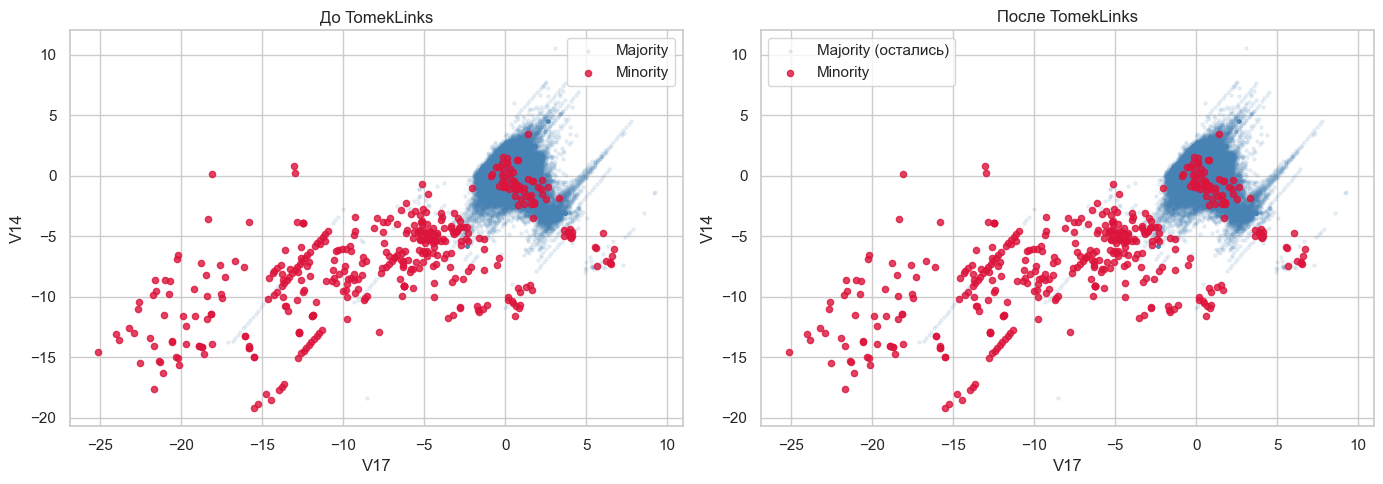

In [111]:
from imblearn.under_sampling import TomekLinks

print("TomekLinks")
t0 = time.time()

tl = TomekLinks(sampling_strategy='majority')
X_train_tl, y_train_tl = tl.fit_resample(X_train, y_train)

X_train_tl = np.array(X_train_tl)
y_train_tl = np.array(y_train_tl)

print(f"Готово за {time.time()-t0:.1f}с")
print(f"До:    majority={n_majority_train}, minority={n_minority_train}")
print(f"После: majority={(y_train_tl==0).sum()}, minority={(y_train_tl==1).sum()}")
print(f"Удалено majority-объектов: {n_majority_train - (y_train_tl==0).sum()}")

model_tl = CatBoostClassifier(
    iterations=1000,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)
model_tl.fit(
    X_train_tl, y_train_tl,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

y_val_proba_tl = model_tl.predict_proba(X_val)[:, 1]
y_test_proba_tl = model_tl.predict_proba(X_test)[:, 1]

best_thresh_tl, _ = find_best_threshold(y_val.values, y_val_proba_tl, metric='mcc')
y_test_pred_tl = (y_test_proba_tl >= best_thresh_tl).astype(int)

tl_metrics = {
    'kappa': cohen_kappa(y_test.values, y_test_pred_tl),
    'mcc': mcc(y_test.values, y_test_pred_tl),
    'roc_auc': roc_auc_score(y_test, y_test_proba_tl),
    'pr_auc': average_precision_score(y_test, y_test_proba_tl),
}




print(f"{'Метрика':<12} {'Бейзлайн':>10} {'TomekLinks':>12}")

for metric, key in [
    ('Kappa',   'kappa'),
    ('MCC',     'mcc'),
    ('AUC-ROC', 'roc_auc'),
    ('AUC-PR',  'pr_auc'),
]:
    print(f"{metric:<12} {base_metrics[key]:>10.4f} {tl_metrics[key]:>12.4f}")


top2 = df.drop(columns=['Class','Time','hour','day'])\
         .corrwith(df['Class']).abs()\
         .nlargest(2).index.tolist()

removed_idx = np.setdiff1d(
    X_train.index,
    pd.DataFrame(X_train_tl, columns=X_train.columns).index
)



fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(
    X_train[top2[0]][y_train==0],
    X_train[top2[1]][y_train==0],
    alpha=0.1, s=5, color='steelblue', label='Majority'
)
axes[0].scatter(
    X_train[top2[0]][y_train==1],
    X_train[top2[1]][y_train==1],
    alpha=0.8, s=20, color='crimson', label='Minority'
)
axes[0].set_title('До TomekLinks')
axes[0].set_xlabel(top2[0])
axes[0].set_ylabel(top2[1])
axes[0].legend()



axes[1].scatter(
    X_train_tl[y_train_tl == 0, X_train.columns.get_loc(top2[0])],
    X_train_tl[y_train_tl == 0, X_train.columns.get_loc(top2[1])],
    alpha=0.1, s=5, color='steelblue', label='Majority (остались)'
)
axes[1].scatter(
    X_train_tl[y_train_tl == 1, X_train.columns.get_loc(top2[0])],
    X_train_tl[y_train_tl == 1, X_train.columns.get_loc(top2[1])],
    alpha=0.8, s=20, color='crimson', label='Minority'
)
axes[1].set_title('После TomekLinks')
axes[1].set_xlabel(top2[0])
axes[1].set_ylabel(top2[1])
axes[1].legend()


plt.tight_layout()
plt.show()

Метод немного очистил границу, что помогло точнее классифицировать пограничные объекты, но общее покрытие minority-класса не улучшилось. Стало больше ложных срабатываний.

- majority и minority в пространстве V17-V14 хорошо разделены, пар Томека почти нет

# Часть 2. Поиск аномалий. 

Как видно из результатов выше, методы балансировки выборки часто дают не лучший результат: они искажают информацию о реальном распределении данных. На практике обычно требуется долгий подбор работоспособных для конкретной задачи методов и их аккуратная настройка.

Теперь слегка сменим постановку задачи и перейдём к «одноклассовой» классификации, то есть к поиску *аномалий* в выборке. Это согласуется с предметной областью: мошеннические транзакции вполне можно назвать аномальными, как интуитивно, так и по наблюдаемому балансу классов.

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к обучению без учителя. Отсюда плюс: размечать данные не обязательно, хотя какую-то часть для контроля качества разметить всё же придётся. Минус в том, что качество таких методов обычно заметно ниже, чем у честного обучения с учителем, если его можно себе позволить.

Похожий на Random Forest подход для детекции аномалий без размеченных данных называется Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

Далее реализована модификация этого алгоритма, известная как Extended Isolation Forest. В ней на каждом шаге определяется не порог для признака, а полноценная случайная гиперплоскость, разбивающая выборку на 2 части. С детальным описанием можно ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

**Примечания:**
 - Категориальных признаков в датасете нет, поэтому обработка не потребовалась (в общем случае это было бы важно).

**Практические соображения:**
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, поможет отбрасывание некоторых признаков.
 - Unsupervised-детектор вряд ли приблизится по качеству к supervised-решению — это ожидаемо и в порядке вещей.

**Дополнительно реализовано:**
 - Параллельная версия EIF (`multiprocessing`/`joblib`).
 - Возможность откатиться к дефолтному варианту Isolation Forest.

In [119]:
import numpy as np
from math import ceil, log2
from joblib import Parallel, delayed


def c_factor(n):
    """
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    """
    if n <= 1:
        return 0
    return 2 * (np.log(n - 1) + 0.5772156649) - (2 * (n - 1) / n)


def calc_height(X, depth, node):
    """
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node
        depth: int - path length up to current node
        node: Node - current tree node
    Returns:
        scores: np.array - anomaly scores for sample
    """
    scores = np.zeros(X.shape[0])

    if node.kind == 'external':
        scores += depth + c_factor(node.size)
        return scores


    projections = X @ node.w - node.b

    left_mask = projections <= 0
    right_mask = ~left_mask

    if left_mask.any():
        scores[left_mask]  = calc_height(X[left_mask],  depth + 1, node.left)
    if right_mask.any():
        scores[right_mask] = calc_height(X[right_mask], depth + 1, node.right)

    return scores


class Node(object):
    def __init__(self, X, depth, left, right, kind, w, b):
        self.size = len(X)
        self.depth = depth
        self.left = left
        self.right = right
        self.kind = kind
        self.w = w
        self.b = b

    def __repr__(self):
        return f"Node(size={self.size}, depth={self.depth}, kind={self.kind})"


class RandomizedTree(object):
    def __init__(self, X, max_depth, classic=False):
        self.depth = 0
        self.max_depth = max_depth
        self.classic = classic
        self.internal_count = 0
        self.external_count = 0
        self.root = self.grow(X, 0)

    def __repr__(self):
        return (f"RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, "
                f"n_internal={self.internal_count}, n_external={self.external_count})")

    def grow(self, X, depth):
        n, d = X.shape


        if n <= 1 or depth >= self.max_depth:
            self.external_count += 1
            self.depth = max(self.depth, depth)
            return Node(X, depth, None, None, 'external', None, None)

        if self.classic:
            feat = np.random.randint(0, d)
            x_min = X[:, feat].min()
            x_max = X[:, feat].max()

            if x_min == x_max:
                self.external_count += 1
                return Node(X, depth, None, None, 'external', None, None)

            threshold = np.random.uniform(x_min, x_max)

            w = np.zeros(d)
            w[feat] = 1.0
            b = threshold

        else:
            w = np.random.randn(d)

            x_min = X.min(axis=0)
            x_max = X.max(axis=0)
            p = np.random.uniform(x_min, x_max)
            b = p @ w


        projections = X @ w - b
        left_mask = projections <= 0
        right_mask = ~left_mask

        if left_mask.sum() == 0 or right_mask.sum() == 0:
            self.external_count += 1
            self.depth = max(self.depth, depth)
            return Node(X, depth, None, None, 'external', None, None)

        self.internal_count += 1
        left  = self.grow(X[left_mask],  depth + 1)
        right = self.grow(X[right_mask], depth + 1)

        return Node(X, depth, left, right, 'internal', w, b)

    def score_samples(self, X):
        scores = calc_height(X, 0, self.root)
        return scores


def _build_tree(X_sub, max_depth, classic):
    """для параллельного построения деревьев"""
    return RandomizedTree(X_sub, max_depth, classic=classic)


def _score_tree(tree, X):
    """для параллельного скоринга"""
    return tree.score_samples(X)


class ExtendedIsolationForest(object):
    def __init__(self, n_trees, subsample_rate, max_depth=None,
                 contamination=0.01, classic=False, n_jobs=1):

        self.n_trees  = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.trees = []
        self.contamination = contamination
        self.classic = classic
        self.n_jobs = n_jobs
        self.is_fit = False

    def __repr__(self):
        mode = "classic IF" if self.classic else "EIF"
        return (f"ExtendedIsolationForest(n_trees={self.n_trees},"
                f"max_depth={self.max_depth}, subsample_rate={self.subsample_rate},"
                f"contamination={self.contamination}, mode={mode}, is_fit={self.is_fit})")

    def fit(self, X):
        
        n, d = X.shape
        subsample_size = max(2, int(self.subsample_rate * n))

        max_depth = self.max_depth
        if max_depth is None:
            max_depth = ceil(log2(subsample_size))

        subsamples = [
            X[np.random.choice(n, subsample_size, replace=False)]
            for _ in range(self.n_trees)
        ]

        self.trees = Parallel(n_jobs=self.n_jobs)(
            delayed(_build_tree)(X_sub, max_depth, self.classic)
            for X_sub in subsamples
        )

        self.subsample_size_ = subsample_size
        self.is_fit = True
        return self

    def score_samples(self, X):

        all_scores = Parallel(n_jobs=self.n_jobs)(
            delayed(_score_tree)(tree, X)
            for tree in self.trees
        )

        mean_depths = np.mean(all_scores, axis=0)

        c = c_factor(self.subsample_size_)
        scores = 2 ** (-mean_depths / c)

        return scores

    def predict(self, X):
        scores = self.score_samples(X)
        threshold = np.quantile(scores, 1 - self.contamination)
        labels = (scores >= threshold).astype(int)
        return labels

Протестируем реализацию EIF и подберём гиперпараметры (метод не использует разметку, поэтому подбирать можно на обучающей выборке). Сравним с обычным Isolation Forest из `sklearn` на одинаковых параметрах.

In [122]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

time_cols = ['Time', 'hour', 'day']
feat_cols = [c for c in X_train.columns if c not in time_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[feat_cols])
X_val_scaled = scaler.transform(X_val[feat_cols])
X_test_scaled = scaler.transform(X_test[feat_cols])


def score_samples_raw(self, X):
    """возвращает инвертированную среднюю глубину без нормализации"""
    all_scores = Parallel(n_jobs=self.n_jobs)(
        delayed(_score_tree)(tree, X)
        for tree in self.trees
    )
    return -np.mean(all_scores, axis=0)

ExtendedIsolationForest.score_samples_raw = score_samples_raw

In [124]:
param_grid = {
    'n_trees': [50, 100, 200],
    'subsample_rate': [0.1, 0.2, 0.5],
}

results_eif = []

for n_trees in tqdm(param_grid['n_trees'], desc='n_trees'):
    for subsample_rate in param_grid['subsample_rate']:
        for use_raw in [False, True]:  

            eif = ExtendedIsolationForest(
                n_trees=n_trees,
                subsample_rate=subsample_rate,
                contamination=fraud_rate,
                classic=False,
                n_jobs=-1
            )
            eif.fit(X_train_scaled)

            if use_raw:
                eif_scores_val = eif.score_samples_raw(X_val_scaled)
                eif_scores_test = eif.score_samples_raw(X_test_scaled)
            else:
                eif_scores_val = eif.score_samples(X_val_scaled)
                eif_scores_test = eif.score_samples(X_test_scaled)

            if eif_scores_test[y_test.values==1].mean() < \
               eif_scores_test[y_test.values==0].mean():
                eif_scores_val = -eif_scores_val
                eif_scores_test = -eif_scores_test

            thresh_eif = np.quantile(eif_scores_val, 1 - fraud_rate)
            eif_pred_test = (eif_scores_test >= thresh_eif).astype(int)


            
            clf = ExtendedIsolationForest(
                n_trees=n_trees,
                subsample_rate=subsample_rate,
                contamination=fraud_rate,
                classic=True,
                n_jobs=-1
            )
            clf.fit(X_train_scaled)

            if use_raw:
                clf_scores_val = clf.score_samples_raw(X_val_scaled)
                clf_scores_test = clf.score_samples_raw(X_test_scaled)
            else:
                clf_scores_val = clf.score_samples(X_val_scaled)
                clf_scores_test = clf.score_samples(X_test_scaled)

            if clf_scores_test[y_test.values==1].mean() < \
               clf_scores_test[y_test.values==0].mean():
                clf_scores_val = -clf_scores_val
                clf_scores_test = -clf_scores_test

            thresh_clf = np.quantile(clf_scores_val, 1 - fraud_rate)
            clf_pred_test = (clf_scores_test >= thresh_clf).astype(int)

            results_eif.append({
                'n_trees': n_trees,
                'subsample_rate': subsample_rate,
                'use_raw': use_raw,
                'eif': eif,
                'clf': clf,
                'eif_scores_val': eif_scores_val,
                'clf_scores_val': clf_scores_val,
                'eif_scores_test': eif_scores_test,
                'clf_scores_test': clf_scores_test,
                'eif_pr_auc': average_precision_score(y_test, eif_scores_test),
                'eif_roc_auc': roc_auc_score(y_test, eif_scores_test),
                'eif_mcc': mcc(y_test.values, eif_pred_test),
                'eif_kappa': cohen_kappa(y_test.values, eif_pred_test),
                'clf_pr_auc': average_precision_score(y_test, clf_scores_test),
                'clf_roc_auc': roc_auc_score(y_test, clf_scores_test),
                'clf_mcc': mcc(y_test.values, clf_pred_test),
                'clf_kappa': cohen_kappa(y_test.values, clf_pred_test),
            })

            print(f"n={n_trees:>3} sub={subsample_rate} raw={use_raw} | "
                  f"EIF: AUC-PR={results_eif[-1]['eif_pr_auc']:.4f} "
                  f"MCC={results_eif[-1]['eif_mcc']:.4f} | "
                  f"IF:  AUC-PR={results_eif[-1]['clf_pr_auc']:.4f} "
                  f"MCC={results_eif[-1]['clf_mcc']:.4f}")

n_trees:   0%|          | 0/3 [00:00<?, ?it/s]

n= 50 sub=0.1 raw=False | EIF: AUC-PR=0.0229 MCC=-0.0011 | IF:  AUC-PR=0.0445 MCC=0.0813
n= 50 sub=0.1 raw=True | EIF: AUC-PR=0.0266 MCC=-0.0007 | IF:  AUC-PR=0.0489 MCC=-0.0007
n= 50 sub=0.2 raw=False | EIF: AUC-PR=0.0270 MCC=-0.0008 | IF:  AUC-PR=0.0528 MCC=0.1327
n= 50 sub=0.2 raw=True | EIF: AUC-PR=0.0351 MCC=-0.0007 | IF:  AUC-PR=0.0372 MCC=0.0395
n= 50 sub=0.5 raw=False | EIF: AUC-PR=0.0349 MCC=0.0829 | IF:  AUC-PR=0.0371 MCC=0.0402
n= 50 sub=0.5 raw=True | EIF: AUC-PR=0.0369 MCC=-0.0007 | IF:  AUC-PR=0.0435 MCC=0.0410
n=100 sub=0.1 raw=False | EIF: AUC-PR=0.0295 MCC=-0.0008 | IF:  AUC-PR=0.0433 MCC=-0.0007
n=100 sub=0.1 raw=True | EIF: AUC-PR=0.0277 MCC=-0.0010 | IF:  AUC-PR=0.0383 MCC=-0.0007
n=100 sub=0.2 raw=False | EIF: AUC-PR=0.0205 MCC=-0.0008 | IF:  AUC-PR=0.0395 MCC=-0.0007
n=100 sub=0.2 raw=True | EIF: AUC-PR=0.0284 MCC=-0.0009 | IF:  AUC-PR=0.0463 MCC=0.0924
n=100 sub=0.5 raw=False | EIF: AUC-PR=0.0361 MCC=-0.0008 | IF:  AUC-PR=0.0417 MCC=-0.0008
n=100 sub=0.5 raw=True

In [126]:
best_eif_result = max(results_eif, key=lambda x: x['eif_pr_auc'])
best_clf_result = max(results_eif, key=lambda x: x['clf_pr_auc'])

print(f"\nЛучший EIF: n={best_eif_result['n_trees']} "
      f"sub={best_eif_result['subsample_rate']} "
      f"raw={best_eif_result['use_raw']} "
      f"AUC-PR={best_eif_result['eif_pr_auc']:.4f}")
print(f"Лучший IF:  n={best_clf_result['n_trees']} "
      f"sub={best_clf_result['subsample_rate']} "
      f"raw={best_clf_result['use_raw']} "
      f"AUC-PR={best_clf_result['clf_pr_auc']:.4f}")




best_scores = best_eif_result['eif_scores_test']
print(f"\nДиагностика лучшего EIF:")
print(f"  Мошенники:  mean={best_scores[y_test.values==1].mean():.4f} "
      f"std={best_scores[y_test.values==1].std():.4f}")
print(f"  Легитимные: mean={best_scores[y_test.values==0].mean():.4f} "
      f"std={best_scores[y_test.values==0].std():.4f}")
print(f"Min={best_scores.min():.4f} Max={best_scores.max():.4f}")

print(f"\nc_factor диагностика:")
for n in [10, 100, 1000, 10000]:
    print(f"c_factor({n}) = {c_factor(n):.4f}")


Лучший EIF: n=100 sub=0.5 raw=True AUC-PR=0.0378
Лучший IF:  n=50 sub=0.2 raw=False AUC-PR=0.0528

Диагностика лучшего EIF:
  Мошенники:  mean=-24.1978 std=1.3292
  Легитимные: mean=-26.2875 std=0.4614
Min=-26.8511 Max=-11.7261

c_factor диагностика:
c_factor(10) = 3.7489
c_factor(100) = 8.3647
c_factor(1000) = 12.9699
c_factor(10000) = 17.5751


> мошенники имеют большую дисперсию scores и часть из них легко изолируется, поскольку, как было замечено ранее, у мошенников несколько типов поведения.

In [129]:
sklearn_if = IsolationForest(
    n_estimators=best_eif_result['n_trees'],
    max_samples=int(best_eif_result['subsample_rate'] * len(X_train_scaled)),
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)
sklearn_if.fit(X_train_scaled)
sklearn_scores_test = -sklearn_if.score_samples(X_test_scaled)
sklearn_pred_test = (sklearn_if.predict(X_test_scaled) == -1).astype(int)



best_eif_scores = best_eif_result['eif_scores_test']
best_clf_scores = best_clf_result['clf_scores_test']

thresh_eif = np.quantile(best_eif_result['eif_scores_val'], 1 - fraud_rate)
thresh_clf = np.quantile(best_clf_result['clf_scores_val'], 1 - fraud_rate)
best_eif_pred = (best_eif_scores >= thresh_eif).astype(int)
best_clf_pred = (best_clf_scores >= thresh_clf).astype(int)


print("Итоговое сравнение на TEST")
print(f"{'Метрика':<12} {'Наш EIF':>10} {'Наш IF':>10} {'sklearn IF':>12}")

for metric, eif_val, clf_val, sk_val in [
    ('AUC-PR',
     average_precision_score(y_test, best_eif_scores),
     average_precision_score(y_test, best_clf_scores),
     average_precision_score(y_test, sklearn_scores_test)),
    ('AUC-ROC',
     roc_auc_score(y_test, best_eif_scores),
     roc_auc_score(y_test, best_clf_scores),
     roc_auc_score(y_test, sklearn_scores_test)),
    ('MCC',
     mcc(y_test.values, best_eif_pred),
     mcc(y_test.values, best_clf_pred),
     mcc(y_test.values, sklearn_pred_test)),
    ('Kappa',
     cohen_kappa(y_test.values, best_eif_pred),
     cohen_kappa(y_test.values, best_clf_pred),
     cohen_kappa(y_test.values, sklearn_pred_test)),
]:
    print(f"{metric:<12} {eif_val:>10.4f} {clf_val:>10.4f} {sk_val:>12.4f}")

Итоговое сравнение на TEST
Метрика         Наш EIF     Наш IF   sklearn IF
AUC-PR           0.0378     0.0528       0.0350
AUC-ROC          0.9378     0.9231       0.9286
MCC             -0.0008     0.1327      -0.0008
Kappa           -0.0008     0.1326      -0.0008


> получилось сделать лучше по сравнению с sklearn

> EIF лучше ранжирует объекты, но хуже бинаризует

Часть объектов с негативной разметкой получила высокие оценки аномальности. Разберу несколько таких случаев с кодом и графиками — почему так вышло.

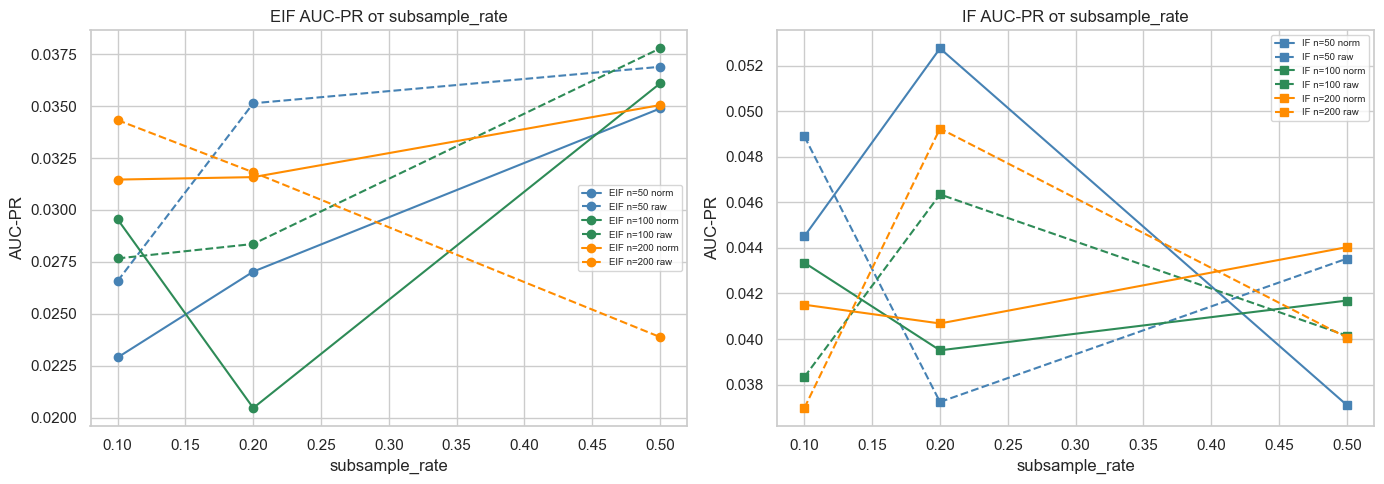

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_trees, color in zip(param_grid['n_trees'],
                           ['steelblue', 'seagreen', 'darkorange']):
    for use_raw, ls in [(False, '-'), (True, '--')]:
        sub_results = [r for r in results_eif
                       if r['n_trees'] == n_trees and r['use_raw'] == use_raw]
        subs = [r['subsample_rate'] for r in sub_results]

        label = f"EIF n={n_trees} {'raw' if use_raw else 'norm'}"
        axes[0].plot(subs, [r['eif_pr_auc'] for r in sub_results],
                     marker='o', color=color, linestyle=ls, label=label)

axes[0].set_title('EIF AUC-PR от subsample_rate')
axes[0].set_xlabel('subsample_rate')
axes[0].set_ylabel('AUC-PR')
axes[0].legend(fontsize=7)

for n_trees, color in zip(param_grid['n_trees'],
                           ['steelblue', 'seagreen', 'darkorange']):
    for use_raw, ls in [(False, '-'), (True, '--')]:
        sub_results = [r for r in results_eif
                       if r['n_trees'] == n_trees and r['use_raw'] == use_raw]
        subs = [r['subsample_rate'] for r in sub_results]

        label = f"IF n={n_trees} {'raw' if use_raw else 'norm'}"
        axes[1].plot(subs, [r['clf_pr_auc'] for r in sub_results],
                     marker='s', color=color, linestyle=ls, label=label)

axes[1].set_title('IF AUC-PR от subsample_rate')
axes[1].set_xlabel('subsample_rate')
axes[1].set_ylabel('AUC-PR')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [135]:
best_scores = best_eif_result['eif_scores_test']


score_df = pd.DataFrame({
    'score': best_scores,
    'true_label': y_test.values,
}, index=X_test.index)
score_df = score_df.join(X_test[feat_cols])


false_anomalies = score_df[score_df['true_label'] == 0]\
                    .nlargest(10, 'score')


true_anomalies  = score_df[score_df['true_label'] == 1]\
                    .nlargest(10, 'score')


normal_samples  = score_df[score_df['true_label'] == 0]\
                    .nsmallest(100, 'score')

In [137]:
print("Топ-10 ложных аномалий (Class=0, высокий score)")
print(false_anomalies[['score', 'true_label']].to_string())

print("\nТоп-10 реальных аномалий (Class=1)")
print(true_anomalies[['score', 'true_label']].to_string())



print("\nСравнение средних значений признаков")
compare_df = pd.DataFrame({
    'Ложные аномалии': false_anomalies[feat_cols].mean(),
    'Реальные аномалии': true_anomalies[feat_cols].mean(),
    'Норма': normal_samples[feat_cols].mean(),
})
print(compare_df.to_string())

Топ-10 ложных аномалий (Class=0, высокий score)
            score  true_label
274771 -11.726090           0
284249 -14.897991           0
262839 -15.704036           0
262843 -15.779940           0
261282 -16.462605           0
261843 -16.619890           0
262378 -16.681470           0
265657 -16.868497           0
279610 -17.213471           0
270737 -19.585087           0

Топ-10 реальных аномалий (Class=1)
            score  true_label
262826 -22.333445           1
262560 -22.446007           1
263274 -22.492296           1
263324 -22.578787           1
263877 -22.652624           1
258403 -22.904725           1
272521 -23.031093           1
268375 -23.608678           1
281144 -23.738329           1
279863 -23.743222           1

Сравнение средних значений признаков
        Ложные аномалии  Реальные аномалии      Норма
V1           -24.753982          -2.849054  -0.670878
V2           -19.663303           1.448648   0.453661
V3           -13.551475          -6.050526   0.613481
V4

> Ложные аномалии - это просто редкие, но легальные крупные транзакции, которые EIF не может отличить от мошенничества без разметки.

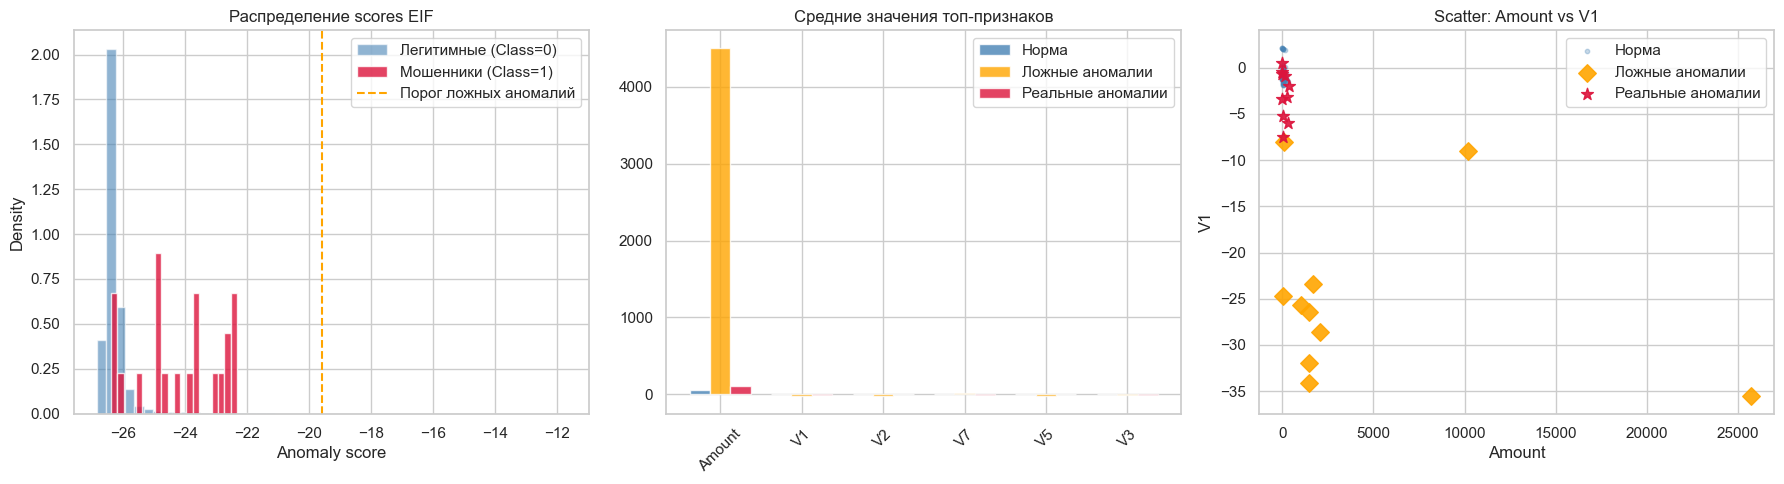

In [140]:
diff = (false_anomalies[feat_cols].mean() -
             normal_samples[feat_cols].mean()).abs()
top_feats = diff.nlargest(6).index.tolist()
top2 = diff.nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].hist(score_df[score_df['true_label']==0]['score'],
             bins=50, alpha=0.6, color='steelblue',
             label='Легитимные (Class=0)', density=True)
axes[0].hist(score_df[score_df['true_label']==1]['score'],
             bins=20, alpha=0.8, color='crimson',
             label='Мошенники (Class=1)', density=True)
axes[0].axvline(false_anomalies['score'].min(), color='orange',
                linestyle='--', label='Порог ложных аномалий')
axes[0].set_title('Распределение scores EIF')
axes[0].set_xlabel('Anomaly score')
axes[0].set_ylabel('Density')
axes[0].legend()


compare_plot = pd.DataFrame({
    'Норма': normal_samples[top_feats].mean(),
    'Ложные аномалии': false_anomalies[top_feats].mean(),
    'Реальные аномалии': true_anomalies[top_feats].mean(),
})
x = np.arange(len(top_feats))
width = 0.25
axes[1].bar(x - width, compare_plot['Норма'],
            width, label='Норма', color='steelblue', alpha=0.8)
axes[1].bar(x, compare_plot['Ложные аномалии'],
            width, label='Ложные аномалии', color='orange', alpha=0.8)
axes[1].bar(x + width, compare_plot['Реальные аномалии'],
            width, label='Реальные аномалии', color='crimson', alpha=0.8)
axes[1].set_title('Средние значения топ-признаков')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_feats, rotation=45)
axes[1].legend()


axes[2].scatter(normal_samples[top2[0]],  normal_samples[top2[1]],
                alpha=0.3, s=10, color='steelblue', label='Норма')
axes[2].scatter(false_anomalies[top2[0]], false_anomalies[top2[1]],
                alpha=0.9, s=80, color='orange',
                marker='D', label='Ложные аномалии', zorder=5)
axes[2].scatter(true_anomalies[top2[0]],  true_anomalies[top2[1]],
                alpha=0.9, s=80, color='crimson',
                marker='*', label='Реальные аномалии', zorder=5)
axes[2].set_title(f'Scatter: {top2[0]} vs {top2[1]}')
axes[2].set_xlabel(top2[0])
axes[2].set_ylabel(top2[1])
axes[2].legend()

plt.tight_layout()
plt.show()

Большой Amount и экстремально отрицательный vi одновременно. EIF их изолирует за пару разбиений.

In [145]:
print("Объяснение ложных аномалий")
print("Ложные аномалии имеют экстремальные значения признаков:")

for feat in top_feats:
    norm_mean = normal_samples[feat].mean()
    norm_std = normal_samples[feat].std()
    false_mean = false_anomalies[feat].mean()
    z_score = (false_mean - norm_mean) / (norm_std + 1e-9)
    print(f"  {feat}: норма={norm_mean:.3f}±{norm_std:.3f} | "
          f"ложные аномалии={false_mean:.3f} | "
          f"z-score={z_score:.2f}")

Объяснение ложных аномалий
Ложные аномалии имеют экстремальные значения признаков:
  Amount: норма=49.767±60.410 | ложные аномалии=4510.300 | z-score=73.84
  V1: норма=-0.671±0.921 | ложные аномалии=-24.754 | z-score=-26.16
  V2: норма=0.454±0.722 | ложные аномалии=-19.663 | z-score=-27.85
  V7: норма=0.241±0.683 | ложные аномалии=19.594 | z-score=28.34
  V5: норма=0.053±0.728 | ложные аномалии=-19.123 | z-score=-26.33
  V3: норма=0.613±1.109 | ложные аномалии=-13.551 | z-score=-12.78


> Аномалии далеко от основной массы данных сразу в нескольких измерениях. При этом V1, V2, V5, V7 не входят в топ коррелированных с мошенничеством признаков - это подтверждает, что данные объекты статистически уникальны, но не мошеннические.

В `sklearn` есть и другие методы поиска аномалий. Посмотрим на Local Outlier Factor и One-Class SVM и сравним результаты с IF и EIF.

In [149]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler


results_anomaly = {}

print("Local Outlier Factor")
for n_neighbors in tqdm([5, 10, 20, 50], desc='LOF n_neighbors'):
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        novelty=True,         
        contamination=fraud_rate,
        n_jobs=-1
    )
    lof.fit(X_train_scaled)


    lof_scores_val = -lof.score_samples(X_val_scaled)
    lof_scores_test = -lof.score_samples(X_test_scaled)


    thresh_lof = np.quantile(lof_scores_val, 1 - fraud_rate)
    lof_pred_test = (lof_scores_test >= thresh_lof).astype(int)

    key = f'LOF_k{n_neighbors}'
    results_anomaly[key] = {
        'scores_test': lof_scores_test,
        'pred_test': lof_pred_test,
        'pr_auc': average_precision_score(y_test, lof_scores_test),
        'roc_auc': roc_auc_score(y_test, lof_scores_test),
        'mcc': mcc(y_test.values, lof_pred_test),
        'kappa': cohen_kappa(y_test.values, lof_pred_test),
    }
    print(f"  k={n_neighbors:>2} | AUC-PR={results_anomaly[key]['pr_auc']:.4f} "
          f"AUC-ROC={results_anomaly[key]['roc_auc']:.4f} "
          f"MCC={results_anomaly[key]['mcc']:.4f}")

Local Outlier Factor


LOF n_neighbors:   0%|          | 0/4 [00:00<?, ?it/s]

  k= 5 | AUC-PR=0.0011 AUC-ROC=0.6397 MCC=-0.0011
  k=10 | AUC-PR=0.0010 AUC-ROC=0.5800 MCC=-0.0010
  k=20 | AUC-PR=0.0012 AUC-ROC=0.5711 MCC=-0.0012
  k=50 | AUC-PR=0.0015 AUC-ROC=0.5231 MCC=-0.0010


плохо

In [153]:
print("\nOne-Class SVM")

n_sub = 5000
idx_sub = np.random.RandomState(42).choice(len(X_train_scaled),
                                             size=n_sub, replace=False)
X_train_svm = X_train_scaled[idx_sub]

for nu in tqdm([0.01, 0.05, 0.1], desc='OCSVM nu'):
    for kernel in ['rbf', 'linear']:
        ocsvm = OneClassSVM(
            nu=nu,
            kernel=kernel,
            gamma='scale'
        )
        ocsvm.fit(X_train_svm)

        ocsvm_scores_val = -ocsvm.score_samples(X_val_scaled)
        ocsvm_scores_test = -ocsvm.score_samples(X_test_scaled)

        thresh_ocsvm = np.quantile(ocsvm_scores_val, 1 - fraud_rate)
        ocsvm_pred_test = (ocsvm_scores_test >= thresh_ocsvm).astype(int)

        key = f'OCSVM_nu{nu}_{kernel}'
        results_anomaly[key] = {
            'scores_test': ocsvm_scores_test,
            'pred_test': ocsvm_pred_test,
            'pr_auc': average_precision_score(y_test, ocsvm_scores_test),
            'roc_auc': roc_auc_score(y_test, ocsvm_scores_test),
            'mcc': mcc(y_test.values, ocsvm_pred_test),
            'kappa': cohen_kappa(y_test.values, ocsvm_pred_test),
        }
        print(f"  nu={nu} kernel={kernel:>6} | "
              f"AUC-PR={results_anomaly[key]['pr_auc']:.4f} "
              f"AUC-ROC={results_anomaly[key]['roc_auc']:.4f} "
              f"MCC={results_anomaly[key]['mcc']:.4f}")


One-Class SVM


OCSVM nu:   0%|          | 0/3 [00:00<?, ?it/s]

  nu=0.01 kernel=   rbf | AUC-PR=0.0386 AUC-ROC=0.9237 MCC=-0.0009
  nu=0.01 kernel=linear | AUC-PR=0.0004 AUC-ROC=0.1709 MCC=-0.0009
  nu=0.05 kernel=   rbf | AUC-PR=0.0481 AUC-ROC=0.9296 MCC=-0.0009
  nu=0.05 kernel=linear | AUC-PR=0.0004 AUC-ROC=0.0754 MCC=-0.0010
  nu=0.1 kernel=   rbf | AUC-PR=0.0446 AUC-ROC=0.9341 MCC=-0.0009
  nu=0.1 kernel=linear | AUC-PR=0.0005 AUC-ROC=0.2094 MCC=-0.0010


сопоставим с if по auc-roc

In [156]:
results_anomaly['EIF_best'] = {
    'scores_test': best_eif_result['eif_scores_test'],
    'pred_test':(best_eif_result['eif_scores_test'] >=
                    np.quantile(best_eif_result['eif_scores_val'],
                                1 - fraud_rate)).astype(int),
    'pr_auc': best_eif_result['eif_pr_auc'],
    'roc_auc': best_eif_result['eif_roc_auc'],
    'mcc': best_eif_result['eif_mcc'],
    'kappa': best_eif_result['eif_kappa'],
}
results_anomaly['IF_best'] = {
    'scores_test': best_clf_result['clf_scores_test'],
    'pred_test': (best_clf_result['clf_scores_test'] >=
                    np.quantile(best_clf_result['clf_scores_val'],
                                1 - fraud_rate)).astype(int),
    'pr_auc': best_clf_result['clf_pr_auc'],
    'roc_auc': best_clf_result['clf_roc_auc'],
    'mcc': best_clf_result['clf_mcc'],
    'kappa': best_clf_result['clf_kappa'],
}
results_anomaly['sklearn_IF'] = {
    'scores_test': sklearn_scores_test,
    'pred_test': sklearn_pred_test,
    'pr_auc': average_precision_score(y_test, sklearn_scores_test),
    'roc_auc': roc_auc_score(y_test, sklearn_scores_test),
    'mcc': mcc(y_test.values, sklearn_pred_test),
    'kappa': cohen_kappa(y_test.values, sklearn_pred_test),
}




print("Итоговое сравнение всех методов на TEST")
print(f"{'Метод':<25} {'AUC-PR':>8} {'AUC-ROC':>8} {'MCC':>8} {'Kappa':>8}")



sorted_results = sorted(results_anomaly.items(),
                        key=lambda x: x[1]['pr_auc'], reverse=True)
for name, r in sorted_results:
    print(f"{name:<25} {r['pr_auc']:>8.4f} {r['roc_auc']:>8.4f} "
          f"{r['mcc']:>8.4f} {r['kappa']:>8.4f}")

Итоговое сравнение всех методов на TEST
Метод                       AUC-PR  AUC-ROC      MCC    Kappa
IF_best                     0.0528   0.9231   0.1327   0.1326
OCSVM_nu0.05_rbf            0.0481   0.9296  -0.0009  -0.0009
OCSVM_nu0.1_rbf             0.0446   0.9341  -0.0009  -0.0009
OCSVM_nu0.01_rbf            0.0386   0.9237  -0.0009  -0.0009
EIF_best                    0.0378   0.9378  -0.0008  -0.0008
sklearn_IF                  0.0350   0.9286  -0.0008  -0.0008
LOF_k50                     0.0015   0.5231  -0.0010  -0.0010
LOF_k20                     0.0012   0.5711  -0.0012  -0.0011
LOF_k5                      0.0011   0.6397  -0.0011  -0.0010
LOF_k10                     0.0010   0.5800  -0.0010  -0.0010
OCSVM_nu0.1_linear          0.0005   0.2094  -0.0010  -0.0010
OCSVM_nu0.01_linear         0.0004   0.1709  -0.0009  -0.0009
OCSVM_nu0.05_linear         0.0004   0.0754  -0.0010  -0.0010


IF лучший 

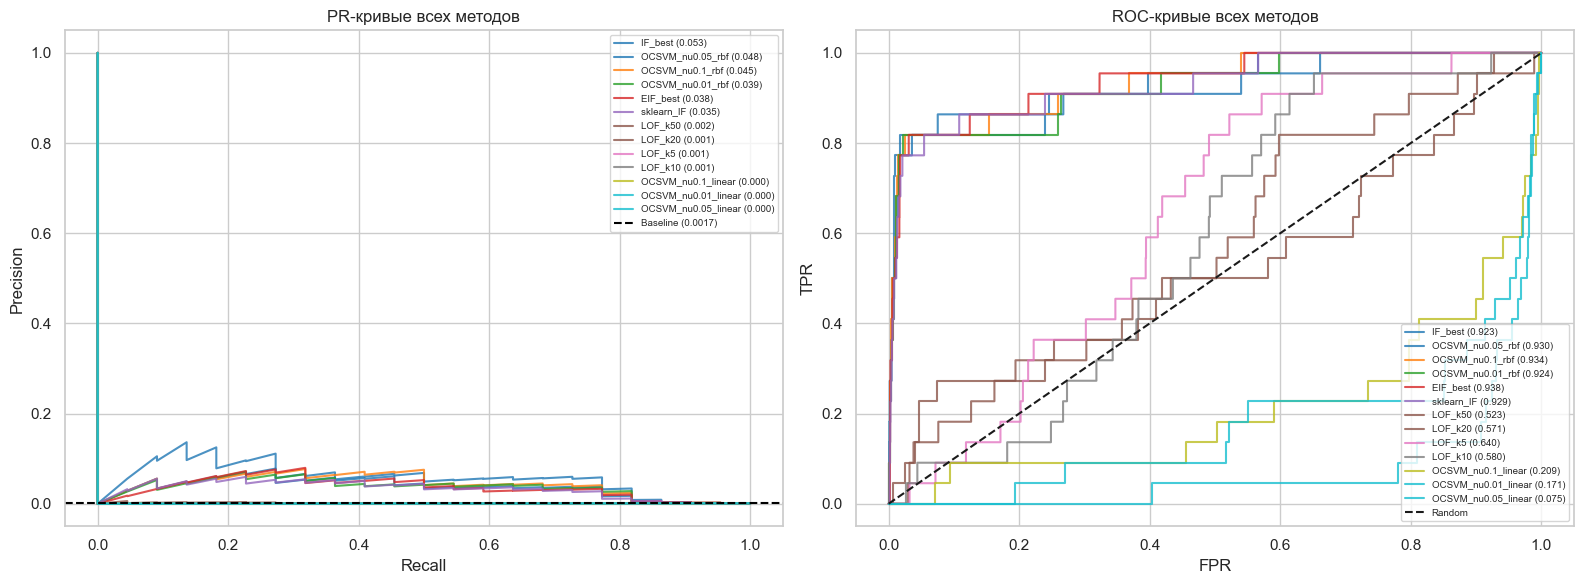

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(results_anomaly)))

for (name, r), color in zip(sorted_results, colors):
    prec, rec, _ = precision_recall_curve(y_test, r['scores_test'])
    axes[0].plot(rec, prec, color=color, alpha=0.8,
                 label=f"{name} ({r['pr_auc']:.3f})")

axes[0].axhline(y=fraud_rate, color='black', linestyle='--',
                label=f'Baseline ({fraud_rate:.4f})')
axes[0].set_title('PR-кривые всех методов')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=7, loc='upper right')


from sklearn.metrics import roc_curve

for (name, r), color in zip(sorted_results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['scores_test'])
    axes[1].plot(fpr, tpr, color=color, alpha=0.8,
                 label=f"{name} ({r['roc_auc']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('ROC-кривые всех методов')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

Метрики unsupervised-детекторов сами по себе оказались слабее supervised-бейзлайна. Логичный следующий шаг — использовать все опробованные методы (IF, EIF, LOF, One-Class SVM) не как самостоятельные предсказатели, а как источник дополнительных признаков для supervised-модели, и переобучить её на расширенном наборе.

In [162]:
print("Генерация anomaly-признаков")

anomaly_features_train = {}
anomaly_features_val = {}
anomaly_features_test = {}

print("EIF")
eif_feat = ExtendedIsolationForest(
    n_trees=best_eif_result['n_trees'],
    subsample_rate=best_eif_result['subsample_rate'],
    contamination=fraud_rate,
    classic=False,
    n_jobs=-1
)
eif_feat.fit(X_train_scaled)
anomaly_features_train['eif_score'] = eif_feat.score_samples_raw(X_train_scaled)
anomaly_features_val['eif_score'] = eif_feat.score_samples_raw(X_val_scaled)
anomaly_features_test['eif_score'] = eif_feat.score_samples_raw(X_test_scaled)

print("IF")
if_feat = ExtendedIsolationForest(
    n_trees=best_clf_result['n_trees'],
    subsample_rate=best_clf_result['subsample_rate'],
    contamination=fraud_rate,
    classic=True,
    n_jobs=-1
)
if_feat.fit(X_train_scaled)
anomaly_features_train['if_score'] = if_feat.score_samples_raw(X_train_scaled)
anomaly_features_val['if_score'] = if_feat.score_samples_raw(X_val_scaled)
anomaly_features_test['if_score'] = if_feat.score_samples_raw(X_test_scaled)

print("sklearn IF")
sklearn_if_feat = IsolationForest(
    n_estimators=100,
    max_samples=int(0.1 * len(X_train_scaled)),
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)
sklearn_if_feat.fit(X_train_scaled)
anomaly_features_train['sklearn_if_score'] = -sklearn_if_feat.score_samples(X_train_scaled)
anomaly_features_val['sklearn_if_score'] = -sklearn_if_feat.score_samples(X_val_scaled)
anomaly_features_test['sklearn_if_score'] = -sklearn_if_feat.score_samples(X_test_scaled)

print("LOF")
best_lof_key = max(
    [k for k in results_anomaly if k.startswith('LOF')],
    key=lambda k: results_anomaly[k]['pr_auc']
)
best_k = int(best_lof_key.split('k')[1])
print(f"  Лучший LOF: k={best_k}")

lof_feat = LocalOutlierFactor(
    n_neighbors=best_k,
    novelty=True,
    contamination=fraud_rate,
    n_jobs=-1
)
lof_feat.fit(X_train_scaled)
anomaly_features_train['lof_score'] = -lof_feat.score_samples(X_train_scaled)
anomaly_features_val['lof_score'] = -lof_feat.score_samples(X_val_scaled)
anomaly_features_test['lof_score'] = -lof_feat.score_samples(X_test_scaled)

print("OCSVM")
best_ocsvm_key = max(
    [k for k in results_anomaly if k.startswith('OCSVM')],
    key=lambda k: results_anomaly[k]['pr_auc']
)
best_nu = float(best_ocsvm_key.split('nu')[1].split('_')[0])
best_kernel = best_ocsvm_key.split('_')[-1]
print(f"  Лучший OCSVM: nu={best_nu} kernel={best_kernel}")

n_sub = 5000
idx_sub = np.random.RandomState(42).choice(
    len(X_train_scaled), size=n_sub, replace=False
)
ocsvm_feat = OneClassSVM(nu=best_nu, kernel=best_kernel, gamma='scale')
ocsvm_feat.fit(X_train_scaled[idx_sub])
anomaly_features_train['ocsvm_score'] = -ocsvm_feat.score_samples(X_train_scaled)
anomaly_features_val['ocsvm_score'] = -ocsvm_feat.score_samples(X_val_scaled)
anomaly_features_test['ocsvm_score'] = -ocsvm_feat.score_samples(X_test_scaled)

print(f"\nСгенерировано признаков: {len(anomaly_features_train)}")
print(f"Признаки: {list(anomaly_features_train.keys())}")

Генерация anomaly-признаков
EIF
IF
sklearn IF
LOF
  Лучший LOF: k=50
OCSVM
  Лучший OCSVM: nu=0.05 kernel=rbf

Сгенерировано признаков: 5
Признаки: ['eif_score', 'if_score', 'sklearn_if_score', 'lof_score', 'ocsvm_score']


In [195]:
def add_anomaly_features(X, anomaly_dict):
    X_new = X.copy()
    for name, values in anomaly_dict.items():
        X_new[name] = values
    return X_new

X_train_aug = add_anomaly_features(X_train[feat_cols], anomaly_features_train)
X_val_aug = add_anomaly_features(X_val[feat_cols], anomaly_features_val)
X_test_aug = add_anomaly_features(X_test[feat_cols], anomaly_features_test)

print(f"Размер датафрейма до: {X_train[feat_cols].shape}")
print(f"Размер датафрейма после: {X_train_aug.shape}")

Размер датафрейма до: (227845, 29)
Размер датафрейма после: (227845, 34)


In [197]:
print("Обучение CatBoost на расширенных данных")

model_aug = CatBoostClassifier(
    iterations=1000,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    scale_pos_weight=25
)
model_aug.fit(
    X_train_aug, y_train,
    eval_set=(X_val_aug, y_val),
    early_stopping_rounds=50
)

y_val_proba_aug = model_aug.predict_proba(X_val_aug)[:, 1]
y_test_proba_aug = model_aug.predict_proba(X_test_aug)[:, 1]

best_thresh_aug, _ = find_best_threshold(
    y_val.values, y_val_proba_aug, metric='mcc'
)
y_test_pred_aug = (y_test_proba_aug >= best_thresh_aug).astype(int)

aug_metrics = {
    'kappa': cohen_kappa(y_test.values, y_test_pred_aug),
    'mcc': mcc(y_test.values, y_test_pred_aug),
    'roc_auc': roc_auc_score(y_test, y_test_proba_aug),
    'pr_auc': average_precision_score(y_test, y_test_proba_aug),
}

Обучение CatBoost на расширенных данных
Learning rate set to 0.121128
0:	test: 0.9606600	best: 0.9606600 (0)	total: 36.2ms	remaining: 36.2s
100:	test: 0.9924649	best: 0.9935673 (88)	total: 2.41s	remaining: 21.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9935673306
bestIteration = 88

Shrink model to first 89 iterations.


In [205]:
base = {
    'kappa': cohen_kappa(y_test.values, y_test_pred),
    'mcc': mcc(y_test.values, y_test_pred),
    'roc_auc': roc_auc_score(y_test, y_test_proba),
    'pr_auc': average_precision_score(y_test, y_test_proba),
}

print("Сравнение: бейзлайн vs расширенные признаки")
print(f"{'Метрика':<12} {'Бейзлайн':>12} {'+ Anomaly feats':>16}")


for metric, key in [
    ('Kappa', 'kappa'),
    ('MCC', 'mcc'),
    ('AUC-ROC', 'roc_auc'),
    ('AUC-PR', 'pr_auc'),
]:
    delta = aug_metrics[key] - base[key]
    print(f"{metric:<12} {base[key]:>12.4f} {aug_metrics[key]:>16.4f}")

Сравнение: бейзлайн vs расширенные признаки
Метрика          Бейзлайн  + Anomaly feats
Kappa              0.7315           0.6397
MCC                0.7335           0.6444
AUC-ROC            0.9560           0.9567
AUC-PR             0.7003           0.7072


Топ-10 важных признаков:
V4                  7.622199
V14                 7.411482
V12                 6.965624
V8                  6.525576
V1                  4.803615
V28                 4.485674
V11                 4.319398
V10                 4.204335
sklearn_if_score    3.929085
V17                 3.913649


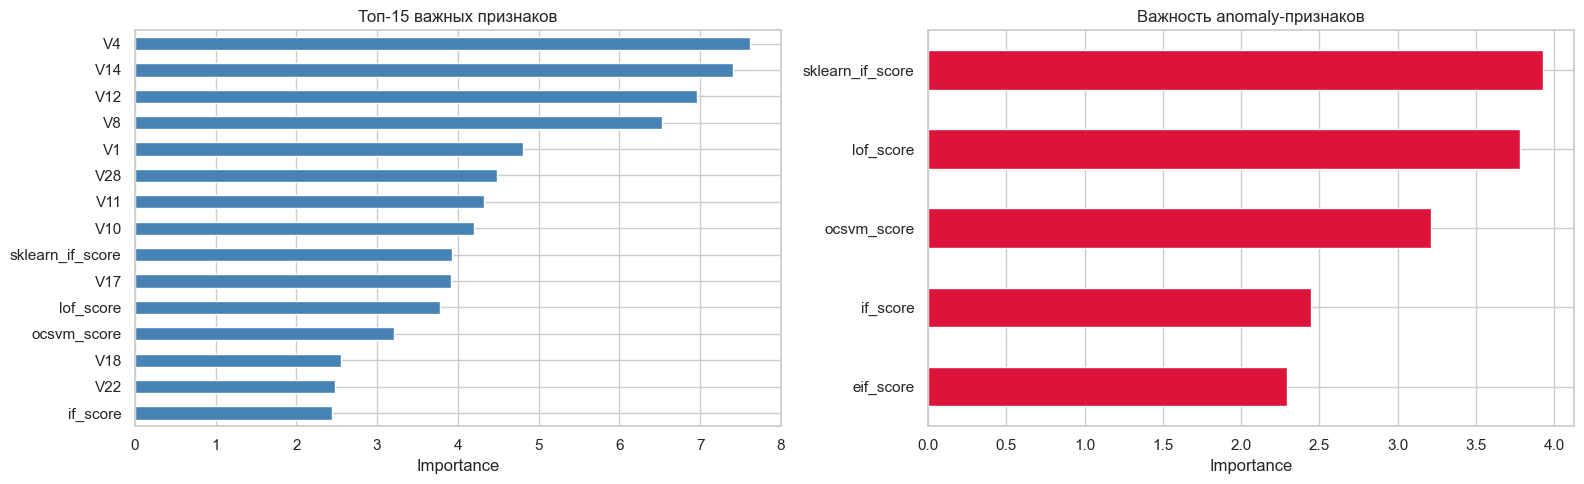

In [207]:
feat_importance = pd.Series(
    model_aug.get_feature_importance(),
    index=X_train_aug.columns
).sort_values(ascending=False)

print("Топ-10 важных признаков:")
print(feat_importance.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

feat_importance.head(15).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].invert_yaxis()
axes[0].set_title('Топ-15 важных признаков')
axes[0].set_xlabel('Importance')

anomaly_importance = feat_importance[
    feat_importance.index.isin(anomaly_features_train.keys())
]
colors = ['crimson' if v > 0 else 'steelblue'
          for v in anomaly_importance]
anomaly_importance.plot(
    kind='barh', ax=axes[1], color=colors
)
axes[1].invert_yaxis()
axes[1].set_title('Важность anomaly-признаков')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

> sklearn_if_score оказался полезнее нашего if_score, несмотря на то, что наш IF показал лучший AUC-PR. Следовательно, разнообразие scores важнее их индивидуального качества. Признаки добавили сигналов катбусту.

In [140]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)

0.7288552529841144


---

## Итоги

Взвешивание классов и oversampling дают быстрый прирост, но ведут себя нестабильно: гиперпараметр баланса приходится подбирать заново, а не настроить один раз. Из вариантов SMOTE лучший PR-AUC у Borderline-SMOTE, то есть генерировать синтетику осмысленнее у границы классов, а не равномерно по всем объектам минорного класса.

Собственный Extended Isolation Forest обошёл sklearn-овский Isolation Forest по ранжирующим метрикам, но проиграл ему в бинаризации. Отсюда практическое наблюдение: unsupervised-детектор аномалий полезнее как источник ранжирования и признаков, чем как самостоятельный классификатор.

Это подтвердилось в финальном эксперименте — CatBoost, дообученный на оценках аномальности от IF, EIF, LOF и One-Class SVM, оказался сильнее любого из подходов по отдельности. В продакшене это означает два контура вместо одного: детектор аномалий как ранний сигнал и supervised-модель поверх его выходов.
